C:\Users\raznu\AppData\Local\Temp\ipykernel_5020\662019496.py:649: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_3_c_d.pdf


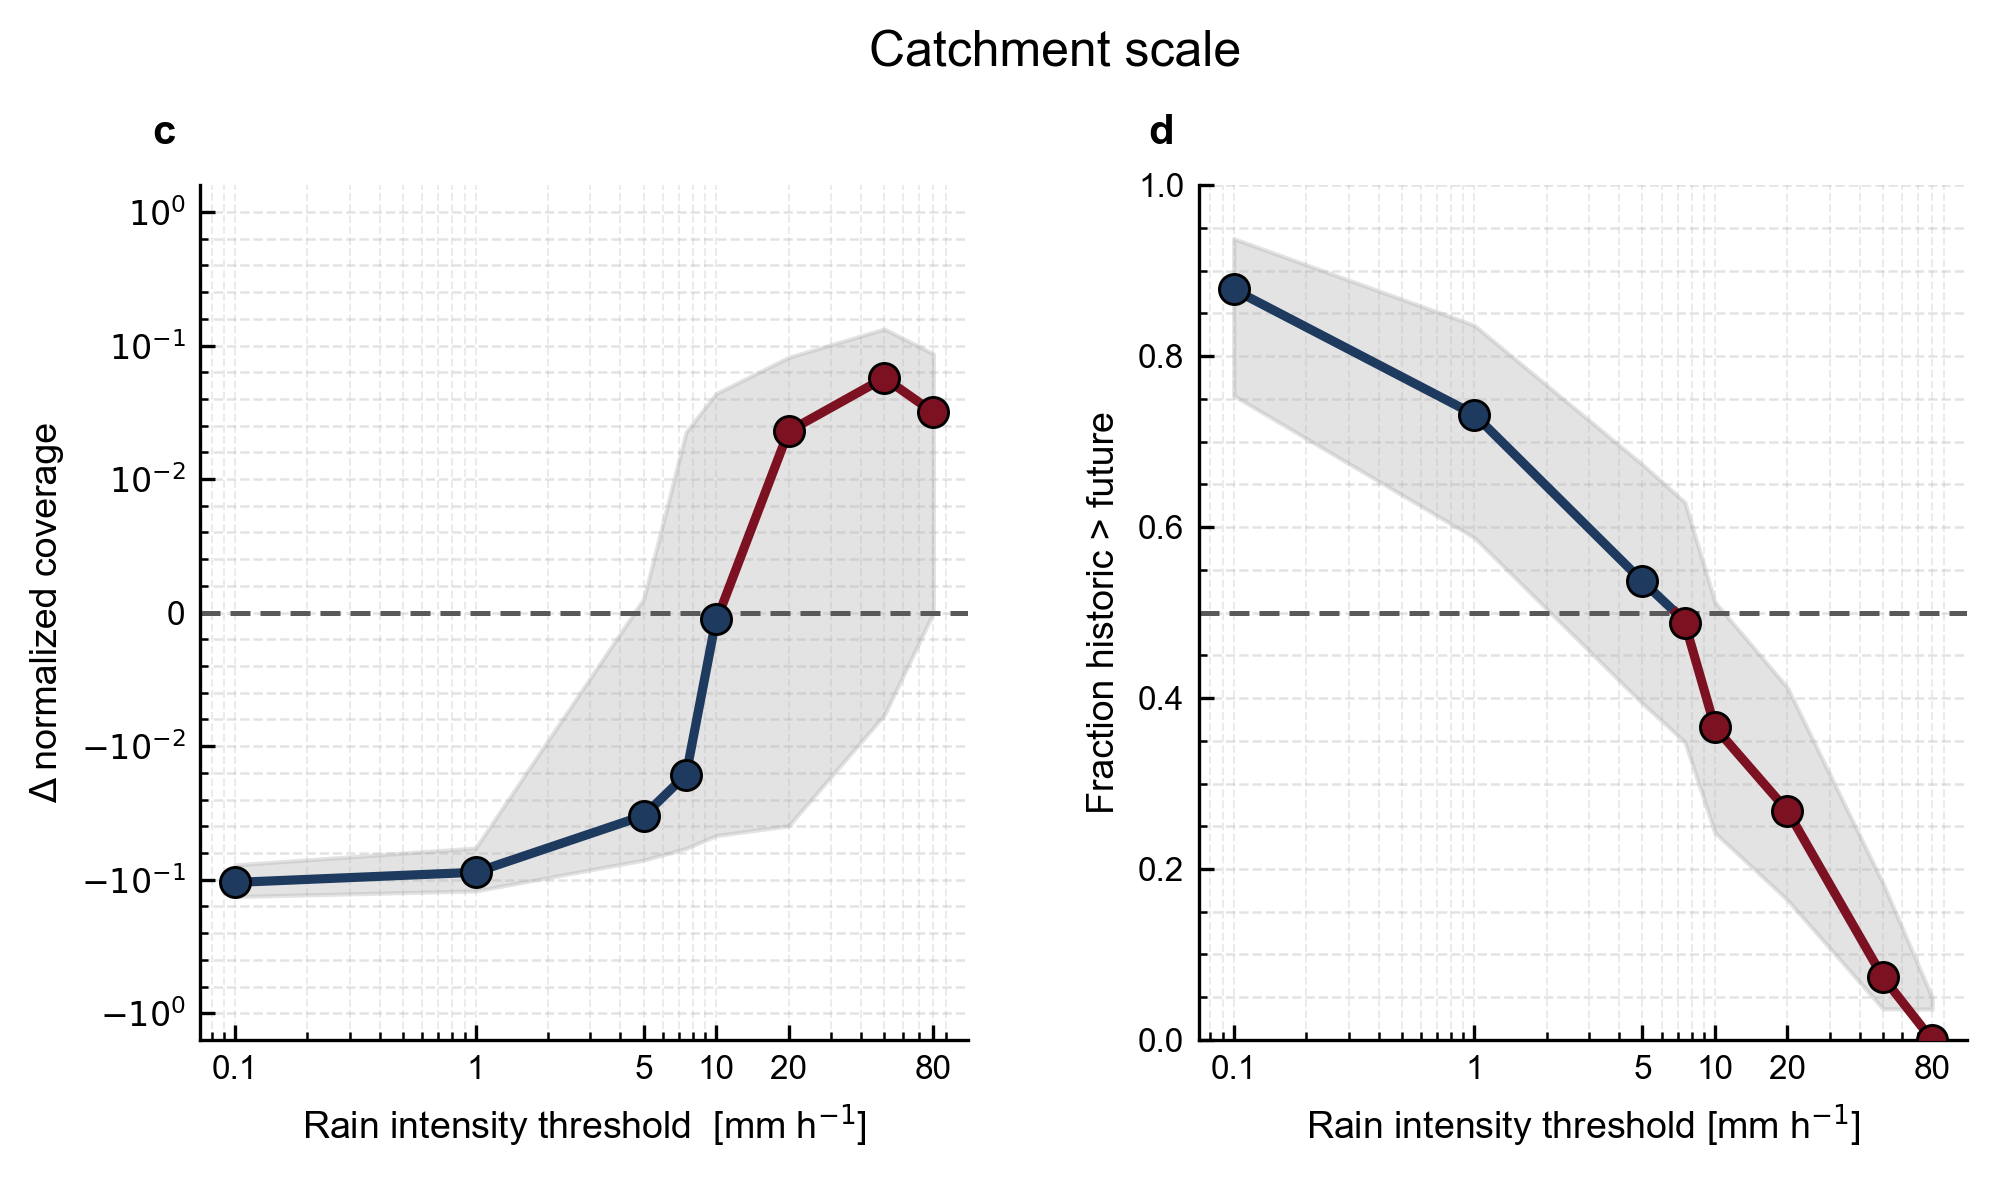

C:\Users\raznu\AppData\Local\Temp\ipykernel_5020\662019496.py:649: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_3_a_b.pdf


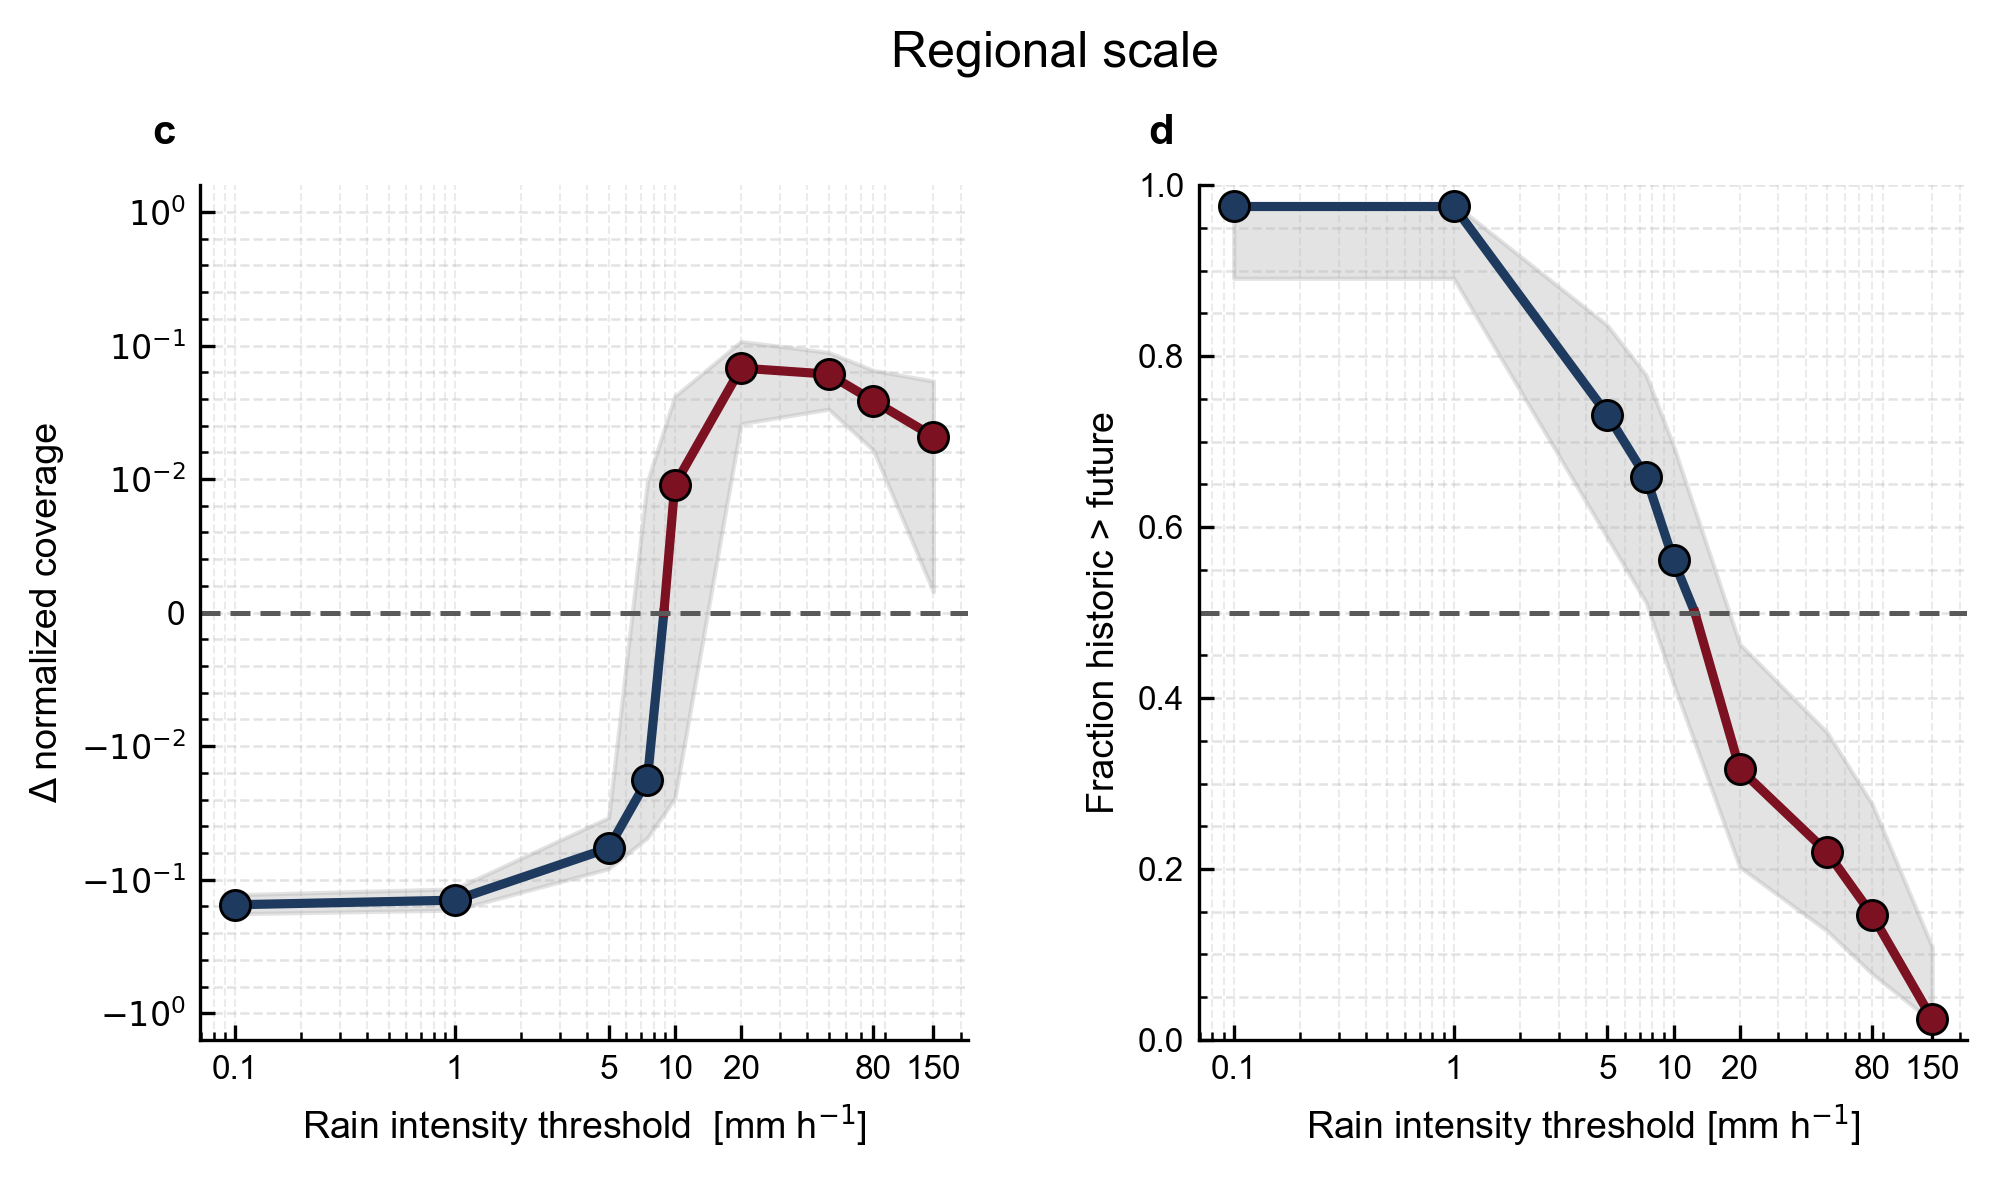

In [6]:
# ============================================
#  Rain only analysis: historical vs future
#  Basin and domain areal coverage
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from contextlib import contextmanager
from pathlib import Path
from typing import Sequence, Optional

# ---------------------------------------------------------------------
# Figure output directory (PDF)
# ---------------------------------------------------------------------

FIG_DIR = Path(
    r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
)

# ---------------------------------------------------------------------
# 1) Load both basin and domain CSV files
# ---------------------------------------------------------------------

DATASETS = {
    "Basin": r"D:\MY_CODES\UrbanRunoffModeling\04_impact_of_climate_change_and_urbanization\wrf_rainfall_analysis\basin_wet_fraction\basin_wet_fraction_events.csv",
    "Domain": r"D:\MY_CODES\UrbanRunoffModeling\04_impact_of_climate_change_and_urbanization\wrf_rainfall_analysis\domain_wet_fraction\domain_wet_fraction_events.csv",
}

# Optional per dataset thresholds to use (mm h^-1).
# None means "use all thresholds in the CSV".
THRESHOLDS_MM_HR = {
    "Basin":  [0.1, 1, 5, 7.5, 10, 20, 50, 80, 150],
    "Domain": [0.1, 1, 5, 7.5, 10, 20, 50, 80, 150],
    # "Basin": None,
}


def load_rain_summary(csv_path: str) -> pd.DataFrame:
    """
    Load a single CSV (basin or domain) and clean basic columns.

    Expected columns in the CSV:
        event_id, scenario, threshold_mm_per_hr, mean_wet_fraction

    Returns a DataFrame with columns:
        event_id (str)
        scenario (str: 'historical' or 'future')
        threshold_mm_hr (float)
        mean_wet_fraction (float, fraction 0–1)
    """
    df = pd.read_csv(csv_path)

    # Standardize threshold column name
    if "threshold_mm_hr" not in df.columns and "threshold_mm_per_hr" in df.columns:
        df = df.rename(columns={"threshold_mm_per_hr": "threshold_mm_hr"})

    expected_cols = {"event_id", "scenario", "threshold_mm_hr", "mean_wet_fraction"}
    missing = expected_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path} is missing columns: {missing}")

    # Clean types
    df["event_id"] = df["event_id"].astype(str)
    df["scenario"] = df["scenario"].astype(str)
    df["threshold_mm_hr"] = pd.to_numeric(df["threshold_mm_hr"], errors="coerce")
    df["mean_wet_fraction"] = pd.to_numeric(df["mean_wet_fraction"], errors="coerce")

    # Drop rows with invalid numeric values
    df = df.dropna(subset=["threshold_mm_hr", "mean_wet_fraction"]).reset_index(drop=True)
    return df


# ---------------------------------------------------------------------
# 2) Build paired table: historic and future side by side
# ---------------------------------------------------------------------

def build_rain_pairs(rain_df: pd.DataFrame) -> pd.DataFrame:
    """
    From long-format table (one row per event × scenario × threshold),
    build paired table with columns:
        threshold_mm_hr
        event_id
        historic_cover   (percentage)
        future_cover     (percentage)
    """
    piv = (
        rain_df
        .pivot_table(
            index=["event_id", "threshold_mm_hr"],
            columns="scenario",
            values="mean_wet_fraction",
            aggfunc="mean"
        )
        .reset_index()
    )

    # We expect columns "historical" and "future" after pivot
    for col in ("historical", "future"):
        if col not in piv.columns:
            raise ValueError(f"Scenario '{col}' missing in pivoted data")

    # Keep only rows where both scenarios are available
    piv = piv.dropna(subset=["historical", "future"]).copy()

    # Rename for clarity
    piv = piv.rename(columns={"historical": "historic_cover",
                              "future": "future_cover"})

    # If numbers are in 0–1 range, convert to percent
    max_val = float(
        np.nanmax([piv["historic_cover"].max(), piv["future_cover"].max()])
    )
    if np.isfinite(max_val) and max_val <= 1.0 + 1e-9:
        piv["historic_cover"] *= 100.0
        piv["future_cover"] *= 100.0

    return piv.sort_values(["threshold_mm_hr", "event_id"], ignore_index=True)


# ---------------------------------------------------------------------
# 3) Normalize per threshold and compute summaries
# ---------------------------------------------------------------------

def normalize_and_summarize_rain(
    pairs: pd.DataFrame,
    norm_method: str = "pooled_max_per_threshold",
    center: str = "mean",
):
    """
    Normalize historic_cover and future_cover and compute summary statistics.
    """
    if pairs.empty:
        raise ValueError("pairs is empty")

    if center not in ("mean", "median"):
        raise ValueError("center must be 'mean' or 'median'")

    data_norm = pairs.copy()
    data_norm["historic_norm"] = np.nan
    data_norm["future_norm"] = np.nan

    # Choose normalization denominator
    if norm_method == "global_hist_max":
        denom = pd.to_numeric(data_norm["historic_cover"], errors="coerce").max()
        if not np.isfinite(denom) or denom == 0:
            raise ValueError("global historic max is not finite or zero")
        data_norm["historic_norm"] = data_norm["historic_cover"] / denom
        data_norm["future_norm"] = data_norm["future_cover"] / denom

    elif norm_method == "pooled_max_per_threshold":
        # For each threshold separately, normalize by the pooled max
        for thr in np.sort(data_norm["threshold_mm_hr"].unique()):
            sel = data_norm["threshold_mm_hr"] == thr
            block = data_norm.loc[sel, ["historic_cover", "future_cover"]].to_numpy(
                dtype=float
            )
            mmax = np.nanmax(block)
            if np.isfinite(mmax) and mmax > 0:
                data_norm.loc[sel, "historic_norm"] = (
                    data_norm.loc[sel, "historic_cover"] / mmax
                )
                data_norm.loc[sel, "future_norm"] = (
                    data_norm.loc[sel, "future_cover"] / mmax
                )
    else:
        raise ValueError(
            "norm_method must be 'pooled_max_per_threshold' or 'global_hist_max'"
        )

    # Drop events that could not be normalized
    data_norm = data_norm.dropna(subset=["historic_norm", "future_norm"]).reset_index(
        drop=True
    )

    # Per threshold center (mean or median)
    agg_fun = center
    means = (
        data_norm
        .groupby("threshold_mm_hr", as_index=False)
        .agg(
            historic_center=("historic_norm", agg_fun),
            future_center=("future_norm", agg_fun),
        )
    )
    means["delta_center"] = means["future_center"] - means["historic_center"]

    # Fraction of events with historic > future
    frac_df = (
        data_norm
        .assign(historic_gt_future=lambda d: d["historic_norm"] > d["future_norm"])
        .groupby("threshold_mm_hr", as_index=False)["historic_gt_future"]
        .mean()
        .rename(columns={"historic_gt_future": "fraction_historic_gt_future"})
    )

    return data_norm, means, frac_df


# ---------------------------------------------------------------------
# 4) Helper functions for styling and transforms
# ---------------------------------------------------------------------

@contextmanager
def nature_rc():
    """
    Context manager that applies a compact 'Nature-style' rcParams block.
    """
    with plt.rc_context({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.labelsize": 9, "axes.titlesize": 10,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "axes.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.minor.visible": True, "ytick.minor.visible": True,
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2.0, "ytick.minor.size": 2.0,
        "legend.frameon": False,
        "savefig.dpi": 300, "figure.dpi": 300,
    }):
        yield


def _apply_axis_nature(ax, grid_y=True, grid_x=False):
    """
    Remove top/right spines and add dashed grids (slightly denser).
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)

    if grid_y:
        ax.grid(True, axis="y", which="both",
                linestyle="--", alpha=0.35, linewidth=0.6)
    if grid_x:
        ax.grid(True, axis="x", which="both",
                linestyle="--", alpha=0.25, linewidth=0.5)


def _adaptive_threshold_ticks(thr: Sequence[float],
                              use_log: bool,
                              max_labels: int = 6):
    """
    Choose a limited set of x ticks based on the threshold values.
    """
    x = np.asarray(thr, float)
    if x.size == 0:
        return np.array([]), []
    xs = np.log10(x) if use_log else x
    span = xs.max() - xs.min()
    if span <= 0 or max_labels < 2:
        ticks = x
    else:
        min_sep = span / (max_labels - 1) * 0.9
        chosen = [0]
        last = xs[0]
        for i in range(1, len(x) - 1):
            if xs[i] - last >= min_sep:
                chosen.append(i)
                last = xs[i]
        if chosen[-1] != len(x) - 1:
            chosen.append(len(x) - 1)
        ticks = x[np.unique(chosen)]
    labels = [f"{t:g}" for t in ticks]
    return ticks, labels


def _compute_per_event_reduce(data_norm: pd.DataFrame,
                              event_reduce: str = "mean") -> pd.DataFrame:
    """
    Reduce normalized coverage per event and threshold.
    """
    if event_reduce not in {"mean", "median"}:
        raise ValueError("event_reduce must be 'mean' or 'median'")

    agg = data_norm.groupby(["threshold_mm_hr", "event_id"], as_index=False).agg(
        historic_event=("historic_norm", event_reduce),
        future_event=("future_norm", event_reduce),
    )
    agg["delta_event"] = agg["future_event"] - agg["historic_event"]
    return agg


def _wilson_ci(p_hat: float, n: int, z: float = 1.96):
    """
    Wilson confidence interval for a binomial proportion.
    """
    if n <= 0 or not np.isfinite(p_hat):
        return np.nan, np.nan
    denom = 1 + z ** 2 / n
    center = (p_hat + z ** 2 / (2 * n)) / denom
    half = (
        z *
        np.sqrt((p_hat * (1 - p_hat) + z ** 2 / (4 * n ** 2)) / n) /
        denom
    )
    return max(0.0, center - half), min(1.0, center + half)


def _pseudo_symlog_transform(values, linthresh=1e-2):
    """
    Custom symmetric transform so that distances between:
    0, 10^-2, 10^-1, 10^0 are equal (and mirrored for negatives).

    Maps:
      0       -> 0
      ±1e-2   -> ±1
      ±1e-1   -> ±2
      ±1      -> ±3
    and interpolates smoothly between them.
    """
    v = np.asarray(values, float)
    out = np.zeros_like(v)
    s = np.sign(v)
    av = np.abs(v)

    # Region 1: |y| < linthresh -> linear: 0 .. 1
    m1 = av < linthresh
    out[m1] = s[m1] * (av[m1] / linthresh) * 1.0

    # Region 2: linthresh <= |y| < 0.1 -> log between 1 .. 2
    m2 = (av >= linthresh) & (av < 0.1)
    if np.any(m2):
        num = np.log10(av[m2]) - np.log10(linthresh)
        den = np.log10(0.1) - np.log10(linthresh)
        out[m2] = s[m2] * (1.0 + num / den * 1.0)

    # Region 3: |y| >= 0.1 -> log between 2 .. 3 (clipped up to 1)
    m3 = av >= 0.1
    if np.any(m3):
        av_clipped = np.clip(av[m3], 0.1, 1.0)
        num = np.log10(av_clipped) - np.log10(0.1)
        den = np.log10(1.0) - np.log10(0.1)
        out[m3] = s[m3] * (2.0 + num / den * 1.0)

    return out


def _plot_splitline(ax, x, y, baseline, color_pos, color_neg, **kw):
    """
    Plot a line where segments above 'baseline' use color_pos
    and segments below 'baseline' use color_neg.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    for i in range(len(x) - 1):
        x0, x1 = x[i], x[i + 1]
        y0, y1 = y[i], y[i + 1]
        if not (np.isfinite(x0) and np.isfinite(x1)
                and np.isfinite(y0) and np.isfinite(y1)):
            continue
        s0, s1 = y0 - baseline, y1 - baseline

        if s0 * s1 > 0:  # same side
            ax.plot([x0, x1], [y0, y1],
                    color=(color_pos if s0 > 0 else color_neg), **kw)
        elif s0 * s1 < 0:  # crosses baseline
            t = (baseline - y0) / (y1 - y0) if y1 != y0 else 0.5
            xc = x0 + t * (x1 - x0)
            ax.plot([x0, xc], [y0, baseline],
                    color=(color_pos if s0 > 0 else color_neg), **kw)
            ax.plot([xc, x1], [baseline, y1],
                    color=(color_pos if s1 > 0 else color_neg), **kw)
        else:  # one exactly on baseline
            ax.plot([x0, x1], [y0, y1],
                    color=(color_pos if s0 >= 0 else color_neg), **kw)


# ---------------------------------------------------------------------
# 5) Bootstrap confidence bands and neutral shading
# ---------------------------------------------------------------------

def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=0):
    """
    Simple bootstrap CI for the mean.
    """
    vals = np.asarray(values, float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        samp = rng.choice(vals, size=vals.size, replace=True)
        boots.append(np.mean(samp))

    lo = np.nanpercentile(boots, 100 * alpha / 2)
    hi = np.nanpercentile(boots, 100 * (1 - alpha / 2))
    return lo, hi


def compute_bootstrap_bands(pe_df, n_boot=2000, alpha=0.05):
    """
    Compute bootstrap confidence bands for delta_event per threshold.
    """
    rows = []
    for thr, sub in pe_df.groupby("threshold_mm_hr"):
        lo, hi = bootstrap_ci(sub["delta_event"].values,
                              n_boot=n_boot,
                              alpha=alpha)
        rows.append((thr, lo, hi))
    return pd.DataFrame(rows, columns=["threshold_mm_hr", "lo", "hi"])


def fill_band_neutral(ax, x, lo, hi, color="#B0B0B0", alpha=0.35):
    """
    Neutral CI band (no split, no baseline logic).
    Works with the custom transformed axis as well.
    """
    x = np.asarray(x, float)
    lo = np.asarray(lo, float)
    hi = np.asarray(hi, float)

    ax.fill_between(
        x,
        lo,
        hi,
        color=color,
        alpha=alpha,
        interpolate=True,
    )


# ---------------------------------------------------------------------
# 6) Final figure: delta coverage and fraction historic > future
# ---------------------------------------------------------------------

def figure_delta_and_fraction_symlog_single_color(
    data_norm: pd.DataFrame,
    means: pd.DataFrame,
    frac_df: pd.DataFrame,
    event_reduce: str = "mean",
    summary_term: str = "mean",  # kept for API compatibility
    auto_log_x: bool = True,
    band_color: str = "#B0B0B0",
    marker_edge: str = "black",
    max_xtick_labels: int = 6,
    symlog_linthresh: float = 0.01,
    symlog_base: float = 10.0,  # kept for interface
    title: Optional[str] = None,
    filename: Optional[str] = None,
    save_dir: Path = FIG_DIR,
    file_format: str = "pdf",
    show: bool = True,
):
    """
    Build the two panel figure and optionally save it as PDF.

    Parameters
    ----------
    title : str or None
        Suptitle for the figure.
    filename : str or None
        Base filename (without extension) to save as PDF.
    save_dir : Path
        Directory to save figure if filename is given.
    file_format : str
        Output format, default 'pdf'.
    show : bool
        If True, show the figure. If False, do not display it.
    """
    col_hist = "#1E3A5F"   # historic-like blue
    col_future = "#7B1121" # future-like red

    # Sort thresholds and compute summary delta per threshold
    ms = means.sort_values("threshold_mm_hr").copy()
    thr = ms["threshold_mm_hr"].astype(float).values
    ms["delta_summary"] = ms["future_center"] - ms["historic_center"]

    # Per event deltas
    pe = _compute_per_event_reduce(data_norm, event_reduce=event_reduce)

    # Bootstrap bands for delta_summary
    band = compute_bootstrap_bands(pe, n_boot=2000, alpha=0.05)
    a_df = (
        ms[["threshold_mm_hr", "delta_summary"]]
        .merge(band, on="threshold_mm_hr", how="left")
        .sort_values("threshold_mm_hr")
    )

    # Prepare data for the right panel
    n_per_thr = (
        data_norm.groupby(["threshold_mm_hr", "event_id"])
        .size()
        .reset_index()
        .groupby("threshold_mm_hr")
        .size()
        .rename("n_events")
        .reset_index()
    )

    b_df = (
        frac_df.merge(n_per_thr, on="threshold_mm_hr", how="left")
        .sort_values("threshold_mm_hr")
    )

    lohi = np.array([
        _wilson_ci(p, int(n))
        for p, n in zip(
            b_df["fraction_historic_gt_future"],
            b_df["n_events"].fillna(0),
        )
    ])
    b_df["lo"], b_df["hi"] = lohi[:, 0], lohi[:, 1]

    # Decide whether to use log x axis
    use_log = False
    if auto_log_x:
        pos = thr[thr > 0]
        use_log = len(pos) >= 2 and (pos.max() / max(pos.min(), 1e-12) >= 20)

    with nature_rc():
        fig, axs = plt.subplots(
            1, 2, figsize=(7.6, 3.7), dpi=300,
            gridspec_kw={"wspace": 0.3}
        )

        # ----------------------------------------------------------
        # (a) Left panel: Δ normalized coverage with custom Y spacing
        # ----------------------------------------------------------
        axL = axs[0]
        if use_log:
            axL.set_xscale("log")

        x = a_df["threshold_mm_hr"].to_numpy(float)
        d = a_df["delta_summary"].to_numpy(float)
        lo = a_df["lo"].to_numpy(float)
        hi = a_df["hi"].to_numpy(float)

        # Transform Y values to pseudo-symlog coordinates
        d_tr  = _pseudo_symlog_transform(d,  linthresh=symlog_linthresh)
        lo_tr = _pseudo_symlog_transform(lo, linthresh=symlog_linthresh)
        hi_tr = _pseudo_symlog_transform(hi, linthresh=symlog_linthresh)

        # Neutral CI band in transformed coordinates
        fill_band_neutral(axL, x, lo_tr, hi_tr, color=band_color, alpha=0.35)

        # Split-colored line in transformed coordinates
        _plot_splitline(axL, x, d_tr, 0.0, color_pos=col_future, color_neg=col_hist, lw=2.2)

        # Markers: future color above zero, historic color below
        pos_mask = d >= 0
        neg_mask = d < 0
        axL.scatter(
            x[pos_mask], d_tr[pos_mask], s=52,
            c=col_future,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )
        axL.scatter(
            x[neg_mask], d_tr[neg_mask], s=52,
            c=col_hist,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )

        # Horizontal zero line
        axL.axhline(0, color="0.35", lw=1.2, ls=(0, (4, 2)))
        axL.set_xlabel("Rain intensity threshold  [mm h$^{-1}$]")
        axL.set_ylabel("Δ normalized coverage")
        _apply_axis_nature(axL, grid_y=True, grid_x=True)

        # X ticks + force tick at threshold 10
        ticks, _ = _adaptive_threshold_ticks(thr, use_log,
                                             max_labels=max_xtick_labels)
        if np.isfinite(thr.min()) and np.isfinite(thr.max()):
            if (thr.min() <= 10.0 <= thr.max()):
                if not np.any(np.isclose(ticks, 10.0)):
                    ticks = np.sort(np.append(ticks, 10.0))
        axL.set_xticks(ticks)
        axL.set_xticklabels([f"{t:g}" for t in ticks])



        # Y limits and labels in transformed space
        axL.set_ylim(-3.2, 3.2)
        axL.set_yticks([-3, -2, -1, 0, 1, 2, 3])
        
        # FIX: Added minus signs to the labels corresponding to negative ticks (-3, -2, -1)
        axL.set_yticklabels(
            ["$-10^{0}$", "$-10^{-1}$", "$-10^{-2}$", "0",
             "$10^{-2}$", "$10^{-1}$", "$10^{0}$"]
        )

        axL.annotate("c", xy=(0, 1), xycoords="axes fraction",
                     xytext=(-6, 8), textcoords="offset points",
                     ha="right", va="bottom", fontweight="bold")



        # ----------------------------------------------------------
        # (b) Right panel: fraction historic > future
        # ----------------------------------------------------------
        axR = axs[1]
        if use_log:
            axR.set_xscale("log")

        x2 = b_df["threshold_mm_hr"].to_numpy(float)
        y = b_df["fraction_historic_gt_future"].to_numpy(float)
        lo2 = b_df["lo"].to_numpy(float)
        hi2 = b_df["hi"].to_numpy(float)
        base = 0.5  # equal probability
 
        # Neutral CI band on [0,1]
        fill_band_neutral(axR, x2, lo2, hi2, color=band_color, alpha=0.35)

        # Split-colored line around 0.5
        _plot_splitline(axR, x2, y, base, color_pos=col_hist, color_neg=col_future, lw=2.2)

        # Markers
        pos2 = y >= base
        neg2 = y < base
        axR.scatter(
            x2[pos2], y[pos2], s=52,
            c=col_hist,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )
        axR.scatter(
            x2[neg2], y[neg2], s=52,
            c=col_future,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )

        axR.axhline(base, color="0.35", lw=1.2, ls=(0, (4, 2)))
        axR.set_ylim(0, 1)
        axR.set_xlabel("Rain intensity threshold [mm h$^{-1}$]")
        axR.set_ylabel("Fraction historic > future")
        _apply_axis_nature(axR, grid_y=True, grid_x=True)

        ticks2, _ = _adaptive_threshold_ticks(thr, use_log,
                                              max_labels=max_xtick_labels)
        if np.isfinite(thr.min()) and np.isfinite(thr.max()):
            if (thr.min() <= 10.0 <= thr.max()):
                if not np.any(np.isclose(ticks2, 10.0)):
                    ticks2 = np.sort(np.append(ticks2, 10.0))
        axR.set_xticks(ticks2)
        axR.set_xticklabels([f"{t:g}" for t in ticks2])

        axR.annotate("d", xy=(0, 1), xycoords="axes fraction",
                     xytext=(-6, 8), textcoords="offset points",
                     ha="right", va="bottom", fontweight="bold")

        # Figure title
        if title is not None:
            fig.suptitle(title, y=1.02)

        plt.tight_layout()

        # Save as PDF if requested
        if filename is not None:
            save_dir.mkdir(parents=True, exist_ok=True)
            out_path = save_dir / f"{filename}.{file_format}"
            fig.savefig(out_path, bbox_inches="tight")
            print(f"Saved figure to: {out_path}")

        if show:
            plt.show()
        else:
            plt.close(fig)

        return fig, axs


# ---------------------------------------------------------------------
# 7) Run the full pipeline for both Basin and Domain
# ---------------------------------------------------------------------

if __name__ == "__main__":

    for label, csv_path in DATASETS.items():
        rain_summary_df = load_rain_summary(csv_path)

        # Optional threshold filtering per dataset
        thr_list = THRESHOLDS_MM_HR.get(label)
        if thr_list is not None:
            thr_arr = np.asarray(thr_list, float)
            rain_summary_df = rain_summary_df[
                rain_summary_df["threshold_mm_hr"].isin(thr_arr)
            ].copy()

        if rain_summary_df.empty:
            raise ValueError(f"No data left after threshold filtering for {label}")

        rain_pairs = build_rain_pairs(rain_summary_df)

        data_norm, means, frac_df = normalize_and_summarize_rain(
            rain_pairs,
            norm_method="pooled_max_per_threshold",
            center="mean",
        )

        # Title and filename per scale
        if label == "Basin":
            title = "Catchment scale"
            filename = "Fig_3_c_d"
        elif label == "Domain":
            title = "Regional scale"
            filename = "Fig_3_a_b"
        else:
            title = f"{label} rain areal coverage"
            filename = f"Fig_3_{label.lower()}"

        figure_delta_and_fraction_symlog_single_color(
            data_norm,
            means,
            frac_df,
            event_reduce="mean",
            summary_term="mean",
            title=title,
            filename=filename,
            save_dir=FIG_DIR,
            file_format="pdf",
            show=True,
        )


## Median insted of mean

C:\Users\raznu\AppData\Local\Temp\ipykernel_5020\1044133544.py:563: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_3_c_d.pdf


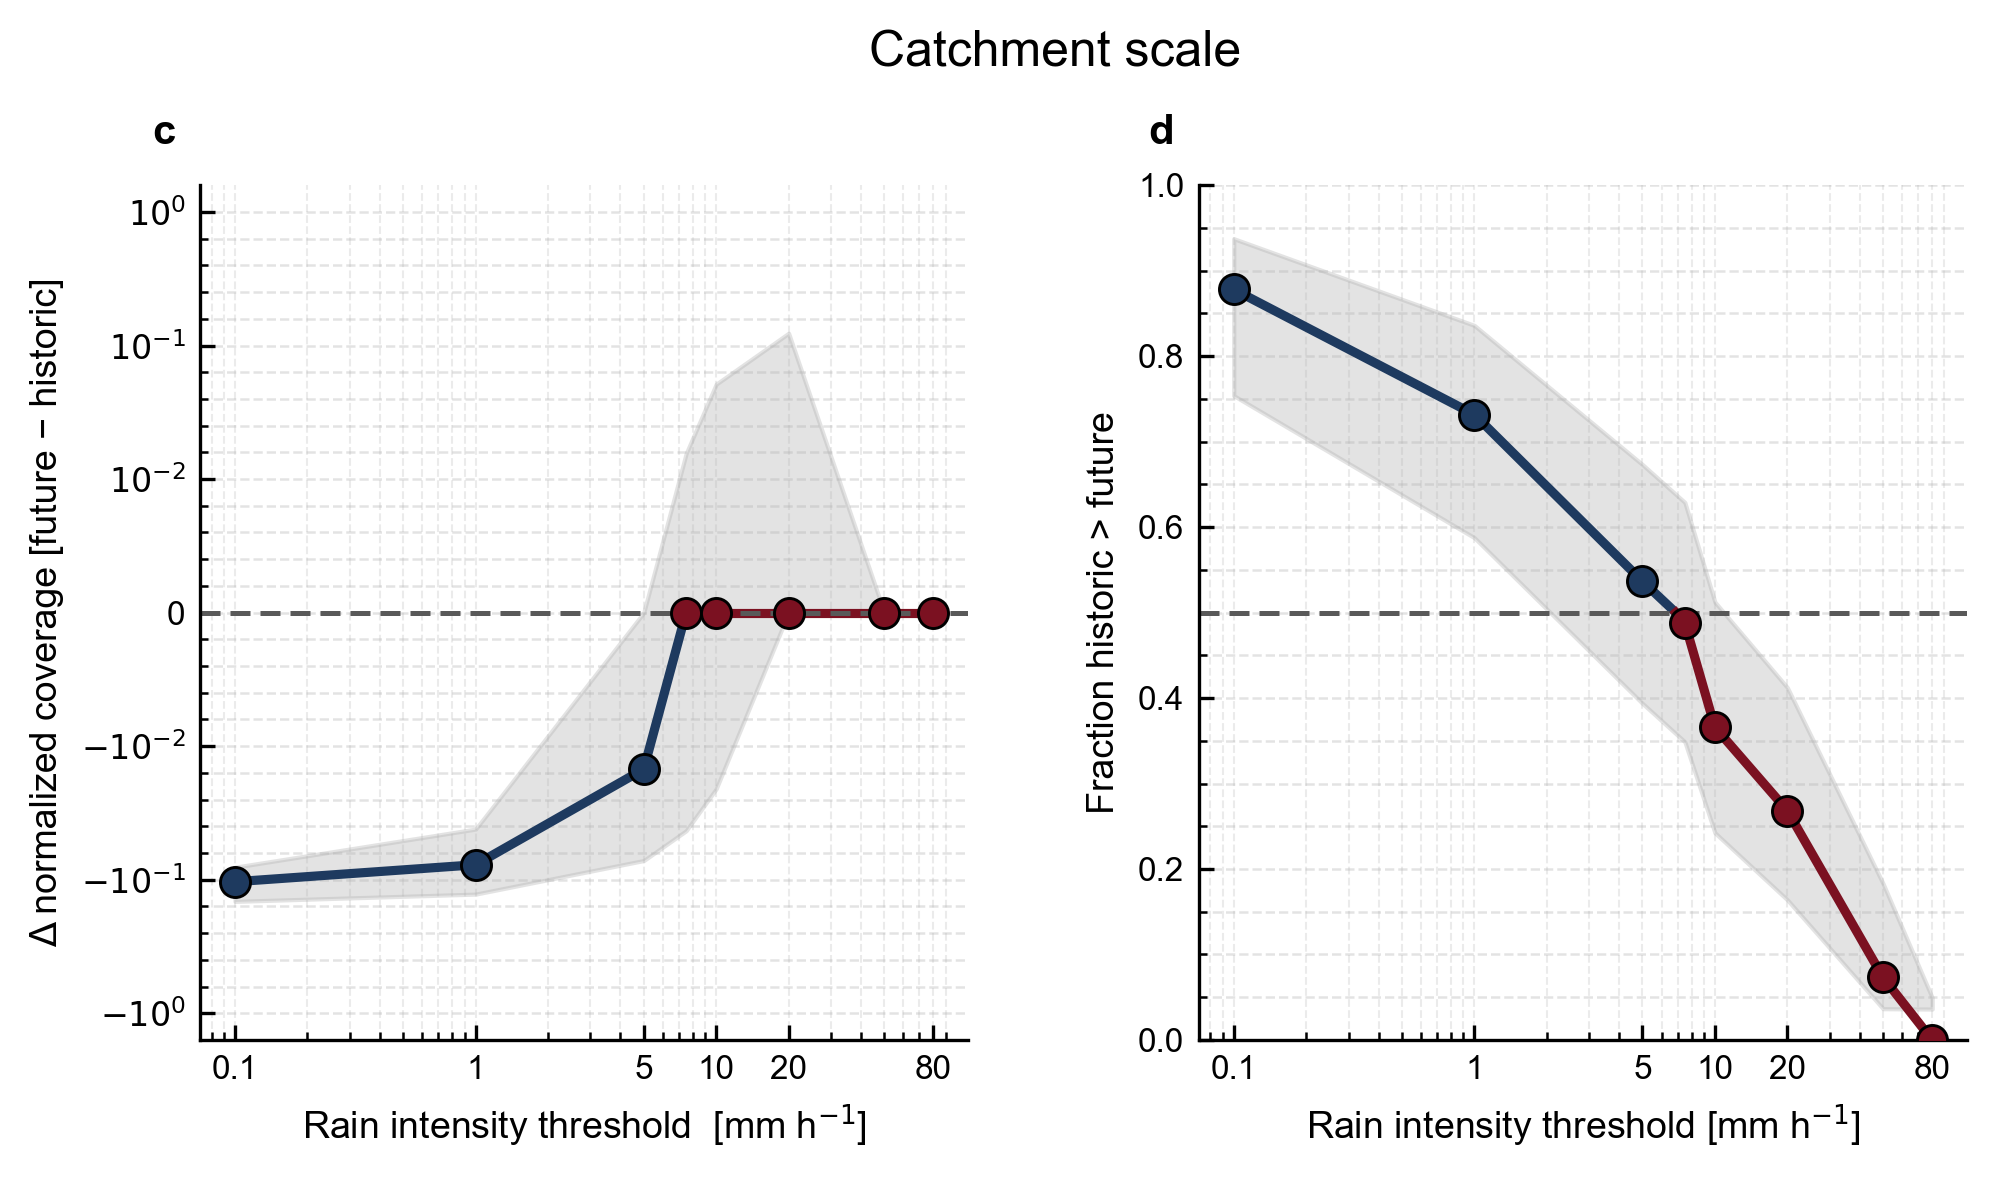

C:\Users\raznu\AppData\Local\Temp\ipykernel_5020\1044133544.py:563: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_3_a_b.pdf


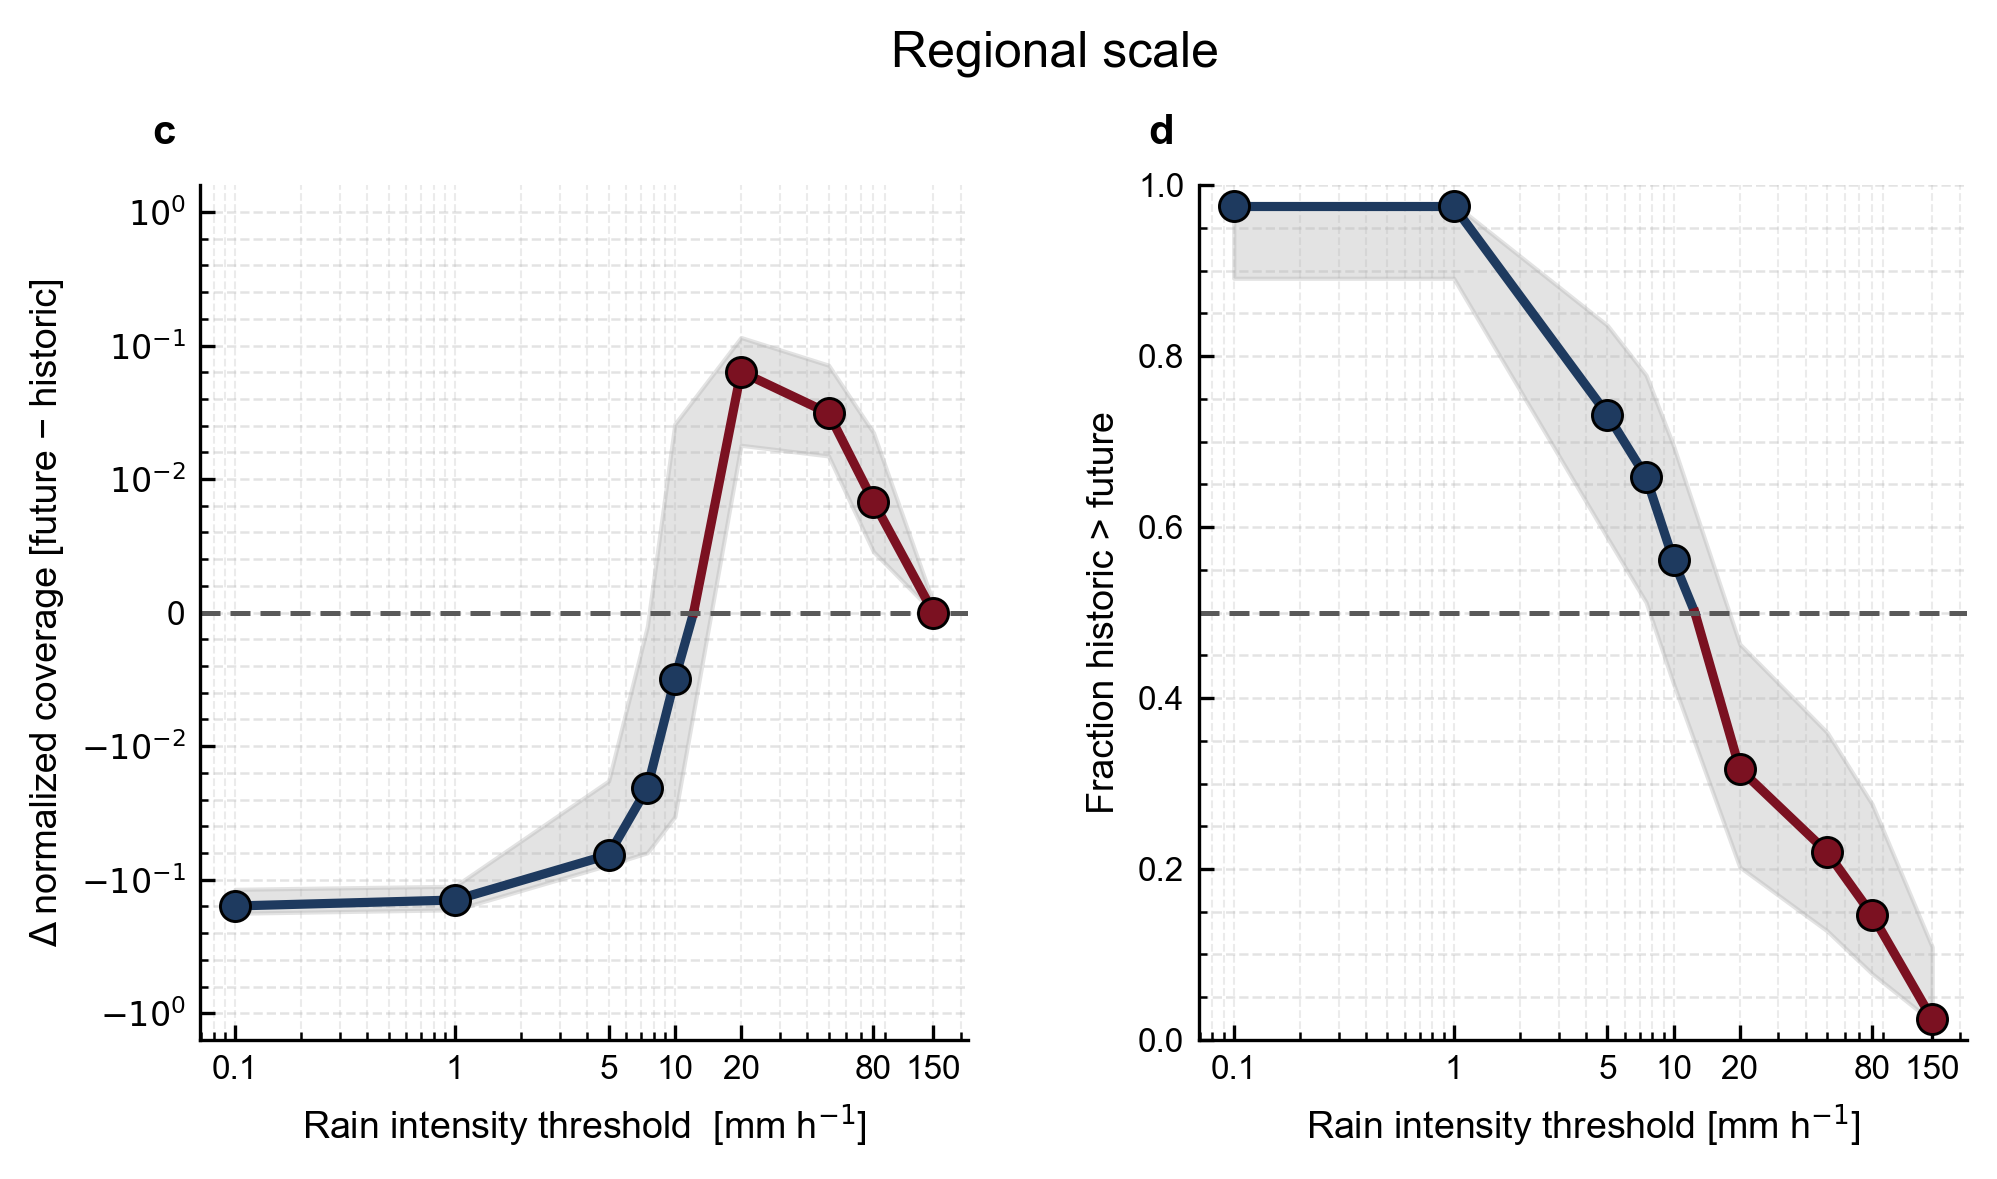

In [4]:
# # ============================================
# #  Rain only analysis: historical vs future
# #  Basin and domain areal coverage
# # ============================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from contextlib import contextmanager
# from pathlib import Path
# from typing import Sequence, Optional

# # ---------------------------------------------------------------------
# # Figure output directory (PDF)
# # ---------------------------------------------------------------------

# FIG_DIR = Path(
#     r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
# )

# # ---------------------------------------------------------------------
# # 1) Load both basin and domain CSV files
# # ---------------------------------------------------------------------

# DATASETS = {
#     "Basin": r"D:\MY_CODES\UrbanRunoffModeling\04_impact_of_climate_change_and_urbanization\wrf_rainfall_analysis\basin_wet_fraction\basin_wet_fraction_events.csv",
#     "Domain": r"D:\MY_CODES\UrbanRunoffModeling\04_impact_of_climate_change_and_urbanization\wrf_rainfall_analysis\domain_wet_fraction\domain_wet_fraction_events.csv",
# }

# # Optional per dataset thresholds to use (mm h^-1).
# # None means "use all thresholds in the CSV".
# THRESHOLDS_MM_HR = {
#     "Basin":  [0.1, 1, 5, 7.5, 10, 20, 50, 80, 150],
#     "Domain": [0.1, 1, 5, 7.5, 10, 20, 50, 80, 150],
# }


# def load_rain_summary(csv_path: str) -> pd.DataFrame:
#     """
#     Load a single CSV (basin or domain) and clean basic columns.

#     Expected columns in the CSV:
#         event_id, scenario, threshold_mm_per_hr, mean_wet_fraction

#     Returns a DataFrame with columns:
#         event_id (str)
#         scenario (str: 'historical' or 'future')
#         threshold_mm_hr (float)
#         mean_wet_fraction (float, fraction 0-1)
#     """
#     df = pd.read_csv(csv_path)

#     if "threshold_mm_hr" not in df.columns and "threshold_mm_per_hr" in df.columns:
#         df = df.rename(columns={"threshold_mm_per_hr": "threshold_mm_hr"})

#     expected_cols = {"event_id", "scenario", "threshold_mm_hr", "mean_wet_fraction"}
#     missing = expected_cols - set(df.columns)
#     if missing:
#         raise ValueError(f"{csv_path} is missing columns: {missing}")

#     df["event_id"] = df["event_id"].astype(str)
#     df["scenario"] = df["scenario"].astype(str)
#     df["threshold_mm_hr"] = pd.to_numeric(df["threshold_mm_hr"], errors="coerce")
#     df["mean_wet_fraction"] = pd.to_numeric(df["mean_wet_fraction"], errors="coerce")

#     df = df.dropna(subset=["threshold_mm_hr", "mean_wet_fraction"]).reset_index(drop=True)
#     return df


# # ---------------------------------------------------------------------
# # 2) Build paired table: historic and future side by side
# # ---------------------------------------------------------------------

# def build_rain_pairs(rain_df: pd.DataFrame) -> pd.DataFrame:
#     """
#     From long-format table (one row per event x scenario x threshold),
#     build paired table with columns:
#         threshold_mm_hr
#         event_id
#         historic_cover   (percentage)
#         future_cover     (percentage)
#     """
#     piv = (
#         rain_df
#         .pivot_table(
#             index=["event_id", "threshold_mm_hr"],
#             columns="scenario",
#             values="mean_wet_fraction",
#             aggfunc="mean"
#         )
#         .reset_index()
#     )

#     for col in ("historical", "future"):
#         if col not in piv.columns:
#             raise ValueError(f"Scenario '{col}' missing in pivoted data")

#     piv = piv.dropna(subset=["historical", "future"]).copy()

#     piv = piv.rename(columns={"historical": "historic_cover",
#                                "future": "future_cover"})

#     max_val = float(
#         np.nanmax([piv["historic_cover"].max(), piv["future_cover"].max()])
#     )
#     if np.isfinite(max_val) and max_val <= 1.0 + 1e-9:
#         piv["historic_cover"] *= 100.0
#         piv["future_cover"] *= 100.0

#     return piv.sort_values(["threshold_mm_hr", "event_id"], ignore_index=True)


# # ---------------------------------------------------------------------
# # 3) Normalize per threshold and compute summaries
# # ---------------------------------------------------------------------

# def normalize_and_summarize_rain(
#     pairs: pd.DataFrame,
#     norm_method: str = "pooled_max_per_threshold",
#     center: str = "mean",
# ):
#     """
#     Normalize historic_cover and future_cover and compute summary statistics.
#     """
#     if pairs.empty:
#         raise ValueError("pairs is empty")

#     if center not in ("mean", "median"):
#         raise ValueError("center must be 'mean' or 'median'")

#     data_norm = pairs.copy()
#     data_norm["historic_norm"] = np.nan
#     data_norm["future_norm"] = np.nan

#     if norm_method == "global_hist_max":
#         denom = pd.to_numeric(data_norm["historic_cover"], errors="coerce").max()
#         if not np.isfinite(denom) or denom == 0:
#             raise ValueError("global historic max is not finite or zero")
#         data_norm["historic_norm"] = data_norm["historic_cover"] / denom
#         data_norm["future_norm"] = data_norm["future_cover"] / denom

#     elif norm_method == "pooled_max_per_threshold":
#         for thr in np.sort(data_norm["threshold_mm_hr"].unique()):
#             sel = data_norm["threshold_mm_hr"] == thr
#             block = data_norm.loc[sel, ["historic_cover", "future_cover"]].to_numpy(
#                 dtype=float
#             )
#             mmax = np.nanmax(block)
#             if np.isfinite(mmax) and mmax > 0:
#                 data_norm.loc[sel, "historic_norm"] = (
#                     data_norm.loc[sel, "historic_cover"] / mmax
#                 )
#                 data_norm.loc[sel, "future_norm"] = (
#                     data_norm.loc[sel, "future_cover"] / mmax
#                 )
#     else:
#         raise ValueError(
#             "norm_method must be 'pooled_max_per_threshold' or 'global_hist_max'"
#         )

#     data_norm = data_norm.dropna(subset=["historic_norm", "future_norm"]).reset_index(
#         drop=True
#     )

#     agg_fun = center
#     means = (
#         data_norm
#         .groupby("threshold_mm_hr", as_index=False)
#         .agg(
#             historic_center=("historic_norm", agg_fun),
#             future_center=("future_norm", agg_fun),
#         )
#     )
#     means["delta_center"] = means["future_center"] - means["historic_center"]

#     frac_df = (
#         data_norm
#         .assign(historic_gt_future=lambda d: d["historic_norm"] > d["future_norm"])
#         .groupby("threshold_mm_hr", as_index=False)["historic_gt_future"]
#         .mean()
#         .rename(columns={"historic_gt_future": "fraction_historic_gt_future"})
#     )

#     return data_norm, means, frac_df


# # ---------------------------------------------------------------------
# # 4) Helper functions for styling and transforms
# # ---------------------------------------------------------------------

# @contextmanager
# def nature_rc():
#     with plt.rc_context({
#         "font.family": "sans-serif",
#         "font.sans-serif": ["Arial", "DejaVu Sans"],
#         "axes.labelsize": 9, "axes.titlesize": 10,
#         "xtick.labelsize": 8, "ytick.labelsize": 8,
#         "axes.linewidth": 0.8,
#         "xtick.direction": "in", "ytick.direction": "in",
#         "xtick.minor.visible": True, "ytick.minor.visible": True,
#         "xtick.major.size": 3.5, "ytick.major.size": 3.5,
#         "xtick.minor.size": 2.0, "ytick.minor.size": 2.0,
#         "legend.frameon": False,
#         "savefig.dpi": 300, "figure.dpi": 300,
#     }):
#         yield


# def _apply_axis_nature(ax, grid_y=True, grid_x=False):
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
#     ax.grid(False)
#     if grid_y:
#         ax.grid(True, axis="y", which="both",
#                 linestyle="--", alpha=0.35, linewidth=0.6)
#     if grid_x:
#         ax.grid(True, axis="x", which="both",
#                 linestyle="--", alpha=0.25, linewidth=0.5)


# def _adaptive_threshold_ticks(thr: Sequence[float],
#                                use_log: bool,
#                                max_labels: int = 6):
#     x = np.asarray(thr, float)
#     if x.size == 0:
#         return np.array([]), []
#     xs = np.log10(x) if use_log else x
#     span = xs.max() - xs.min()
#     if span <= 0 or max_labels < 2:
#         ticks = x
#     else:
#         min_sep = span / (max_labels - 1) * 0.9
#         chosen = [0]
#         last = xs[0]
#         for i in range(1, len(x) - 1):
#             if xs[i] - last >= min_sep:
#                 chosen.append(i)
#                 last = xs[i]
#         if chosen[-1] != len(x) - 1:
#             chosen.append(len(x) - 1)
#         ticks = x[np.unique(chosen)]
#     labels = [f"{t:g}" for t in ticks]
#     return ticks, labels


# def _compute_per_event_reduce(data_norm: pd.DataFrame,
#                                event_reduce: str = "mean") -> pd.DataFrame:
#     if event_reduce not in {"mean", "median"}:
#         raise ValueError("event_reduce must be 'mean' or 'median'")

#     agg = data_norm.groupby(["threshold_mm_hr", "event_id"], as_index=False).agg(
#         historic_event=("historic_norm", event_reduce),
#         future_event=("future_norm", event_reduce),
#     )
#     agg["delta_event"] = agg["future_event"] - agg["historic_event"]
#     return agg


# def _wilson_ci(p_hat: float, n: int, z: float = 1.96):
#     if n <= 0 or not np.isfinite(p_hat):
#         return np.nan, np.nan
#     denom = 1 + z ** 2 / n
#     center = (p_hat + z ** 2 / (2 * n)) / denom
#     half = (
#         z *
#         np.sqrt((p_hat * (1 - p_hat) + z ** 2 / (4 * n ** 2)) / n) /
#         denom
#     )
#     return max(0.0, center - half), min(1.0, center + half)


# def _pseudo_symlog_transform(values, linthresh=1e-2):
#     v = np.asarray(values, float)
#     out = np.zeros_like(v)
#     s = np.sign(v)
#     av = np.abs(v)

#     m1 = av < linthresh
#     out[m1] = s[m1] * (av[m1] / linthresh) * 1.0

#     m2 = (av >= linthresh) & (av < 0.1)
#     if np.any(m2):
#         num = np.log10(av[m2]) - np.log10(linthresh)
#         den = np.log10(0.1) - np.log10(linthresh)
#         out[m2] = s[m2] * (1.0 + num / den * 1.0)

#     m3 = av >= 0.1
#     if np.any(m3):
#         av_clipped = np.clip(av[m3], 0.1, 1.0)
#         num = np.log10(av_clipped) - np.log10(0.1)
#         den = np.log10(1.0) - np.log10(0.1)
#         out[m3] = s[m3] * (2.0 + num / den * 1.0)

#     return out


# def _plot_splitline(ax, x, y, baseline, color_pos, color_neg, **kw):
#     x = np.asarray(x, float)
#     y = np.asarray(y, float)
#     for i in range(len(x) - 1):
#         x0, x1 = x[i], x[i + 1]
#         y0, y1 = y[i], y[i + 1]
#         if not (np.isfinite(x0) and np.isfinite(x1)
#                 and np.isfinite(y0) and np.isfinite(y1)):
#             continue
#         s0, s1 = y0 - baseline, y1 - baseline

#         if s0 * s1 > 0:
#             ax.plot([x0, x1], [y0, y1],
#                     color=(color_pos if s0 > 0 else color_neg), **kw)
#         elif s0 * s1 < 0:
#             t = (baseline - y0) / (y1 - y0) if y1 != y0 else 0.5
#             xc = x0 + t * (x1 - x0)
#             ax.plot([x0, xc], [y0, baseline],
#                     color=(color_pos if s0 > 0 else color_neg), **kw)
#             ax.plot([xc, x1], [baseline, y1],
#                     color=(color_pos if s1 > 0 else color_neg), **kw)
#         else:
#             ax.plot([x0, x1], [y0, y1],
#                     color=(color_pos if s0 >= 0 else color_neg), **kw)


# # ---------------------------------------------------------------------
# # 5) Bootstrap confidence bands and neutral shading
# # ---------------------------------------------------------------------

# def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=0):
#     vals = np.asarray(values, float)
#     vals = vals[np.isfinite(vals)]
#     if vals.size == 0:
#         return np.nan, np.nan

#     rng = np.random.default_rng(seed)
#     boots = []
#     for _ in range(n_boot):
#         samp = rng.choice(vals, size=vals.size, replace=True)
#         boots.append(np.median(samp))  # <-- median of bootstrapped samples

#     lo = np.nanpercentile(boots, 100 * alpha / 2)
#     hi = np.nanpercentile(boots, 100 * (1 - alpha / 2))
#     return lo, hi


# def compute_bootstrap_bands(pe_df, n_boot=2000, alpha=0.05):
#     rows = []
#     for thr, sub in pe_df.groupby("threshold_mm_hr"):
#         lo, hi = bootstrap_ci(sub["delta_event"].values,
#                                n_boot=n_boot,
#                                alpha=alpha)
#         rows.append((thr, lo, hi))
#     return pd.DataFrame(rows, columns=["threshold_mm_hr", "lo", "hi"])


# def fill_band_neutral(ax, x, lo, hi, color="#B0B0B0", alpha=0.35):
#     x = np.asarray(x, float)
#     lo = np.asarray(lo, float)
#     hi = np.asarray(hi, float)

#     ax.fill_between(
#         x,
#         lo,
#         hi,
#         color=color,
#         alpha=alpha,
#         interpolate=True,
#     )


# # ---------------------------------------------------------------------
# # 6) Final figure: delta coverage and fraction historic > future
# # ---------------------------------------------------------------------

# def figure_delta_and_fraction_symlog_single_color(
#     data_norm: pd.DataFrame,
#     means: pd.DataFrame,
#     frac_df: pd.DataFrame,
#     event_reduce: str = "mean",
#     summary_term: str = "mean",
#     auto_log_x: bool = True,
#     band_color: str = "#B0B0B0",
#     marker_edge: str = "black",
#     max_xtick_labels: int = 6,
#     symlog_linthresh: float = 0.01,
#     symlog_base: float = 10.0,
#     title: Optional[str] = None,
#     filename: Optional[str] = None,
#     save_dir: Path = FIG_DIR,
#     file_format: str = "pdf",
#     show: bool = True,
# ):
#     col_hist = "#1E3A5F"
#     col_future = "#7B1121"

#     ms = means.sort_values("threshold_mm_hr").copy()
#     thr = ms["threshold_mm_hr"].astype(float).values

#     # -----------------------------------------------------------------
#     # Compute per-event deltas FIRST, then use median of delta_event
#     # as the summary statistic (instead of future_center - historic_center)
#     # -----------------------------------------------------------------
#     pe = _compute_per_event_reduce(data_norm, event_reduce=event_reduce)

#     ms["delta_summary"] = (
#         pe.groupby("threshold_mm_hr")["delta_event"]
#         .median()
#         .reindex(ms["threshold_mm_hr"].values)
#         .values
#     )

#     # Bootstrap bands for delta_summary (bootstrapping the median)
#     band = compute_bootstrap_bands(pe, n_boot=2000, alpha=0.05)
#     a_df = (
#         ms[["threshold_mm_hr", "delta_summary"]]
#         .merge(band, on="threshold_mm_hr", how="left")
#         .sort_values("threshold_mm_hr")
#     )

#     # Prepare data for the right panel
#     n_per_thr = (
#         data_norm.groupby(["threshold_mm_hr", "event_id"])
#         .size()
#         .reset_index()
#         .groupby("threshold_mm_hr")
#         .size()
#         .rename("n_events")
#         .reset_index()
#     )

#     b_df = (
#         frac_df.merge(n_per_thr, on="threshold_mm_hr", how="left")
#         .sort_values("threshold_mm_hr")
#     )

#     lohi = np.array([
#         _wilson_ci(p, int(n))
#         for p, n in zip(
#             b_df["fraction_historic_gt_future"],
#             b_df["n_events"].fillna(0),
#         )
#     ])
#     b_df["lo"], b_df["hi"] = lohi[:, 0], lohi[:, 1]

#     use_log = False
#     if auto_log_x:
#         pos = thr[thr > 0]
#         use_log = len(pos) >= 2 and (pos.max() / max(pos.min(), 1e-12) >= 20)

#     with nature_rc():
#         fig, axs = plt.subplots(
#             1, 2, figsize=(7.6, 3.7), dpi=300,
#             gridspec_kw={"wspace": 0.3}
#         )

#         # ----------------------------------------------------------
#         # (a) Left panel: delta normalized coverage
#         # ----------------------------------------------------------
#         axL = axs[0]
#         if use_log:
#             axL.set_xscale("log")

#         x = a_df["threshold_mm_hr"].to_numpy(float)
#         d = a_df["delta_summary"].to_numpy(float)
#         lo = a_df["lo"].to_numpy(float)
#         hi = a_df["hi"].to_numpy(float)

#         d_tr  = _pseudo_symlog_transform(d,  linthresh=symlog_linthresh)
#         lo_tr = _pseudo_symlog_transform(lo, linthresh=symlog_linthresh)
#         hi_tr = _pseudo_symlog_transform(hi, linthresh=symlog_linthresh)

#         fill_band_neutral(axL, x, lo_tr, hi_tr, color=band_color, alpha=0.35)
#         _plot_splitline(axL, x, d_tr, 0.0, color_pos=col_future, color_neg=col_hist, lw=2.2)

#         pos_mask = d >= 0
#         neg_mask = d < 0
#         axL.scatter(
#             x[pos_mask], d_tr[pos_mask], s=52,
#             c=col_future,
#             edgecolors=marker_edge, linewidths=0.7, zorder=3
#         )
#         axL.scatter(
#             x[neg_mask], d_tr[neg_mask], s=52,
#             c=col_hist,
#             edgecolors=marker_edge, linewidths=0.7, zorder=3
#         )

#         axL.axhline(0, color="0.35", lw=1.2, ls=(0, (4, 2)))
#         axL.set_xlabel("Rain intensity threshold  [mm h$^{-1}$]")
#         axL.set_ylabel("Δ normalized coverage [future − historic]")
#         _apply_axis_nature(axL, grid_y=True, grid_x=True)

#         ticks, _ = _adaptive_threshold_ticks(thr, use_log,
#                                               max_labels=max_xtick_labels)
#         if np.isfinite(thr.min()) and np.isfinite(thr.max()):
#             if thr.min() <= 10.0 <= thr.max():
#                 if not np.any(np.isclose(ticks, 10.0)):
#                     ticks = np.sort(np.append(ticks, 10.0))
#         axL.set_xticks(ticks)
#         axL.set_xticklabels([f"{t:g}" for t in ticks])

#         axL.set_ylim(-3.2, 3.2)
#         axL.set_yticks([-3, -2, -1, 0, 1, 2, 3])
#         axL.set_yticklabels(
#             ["$-10^{0}$", "$-10^{-1}$", "$-10^{-2}$", "0",
#              "$10^{-2}$", "$10^{-1}$", "$10^{0}$"]
#         )

#         axL.annotate("c", xy=(0, 1), xycoords="axes fraction",
#                      xytext=(-6, 8), textcoords="offset points",
#                      ha="right", va="bottom", fontweight="bold")

#         # ----------------------------------------------------------
#         # (b) Right panel: fraction historic > future
#         # ----------------------------------------------------------
#         axR = axs[1]
#         if use_log:
#             axR.set_xscale("log")

#         x2 = b_df["threshold_mm_hr"].to_numpy(float)
#         y = b_df["fraction_historic_gt_future"].to_numpy(float)
#         lo2 = b_df["lo"].to_numpy(float)
#         hi2 = b_df["hi"].to_numpy(float)
#         base = 0.5

#         fill_band_neutral(axR, x2, lo2, hi2, color=band_color, alpha=0.35)
#         _plot_splitline(axR, x2, y, base, color_pos=col_hist, color_neg=col_future, lw=2.2)

#         pos2 = y >= base
#         neg2 = y < base
#         axR.scatter(
#             x2[pos2], y[pos2], s=52,
#             c=col_hist,
#             edgecolors=marker_edge, linewidths=0.7, zorder=3
#         )
#         axR.scatter(
#             x2[neg2], y[neg2], s=52,
#             c=col_future,
#             edgecolors=marker_edge, linewidths=0.7, zorder=3
#         )

#         axR.axhline(base, color="0.35", lw=1.2, ls=(0, (4, 2)))
#         axR.set_ylim(0, 1)
#         axR.set_xlabel("Rain intensity threshold [mm h$^{-1}$]")
#         axR.set_ylabel("Fraction historic > future")
#         _apply_axis_nature(axR, grid_y=True, grid_x=True)

#         ticks2, _ = _adaptive_threshold_ticks(thr, use_log,
#                                                max_labels=max_xtick_labels)
#         if np.isfinite(thr.min()) and np.isfinite(thr.max()):
#             if thr.min() <= 10.0 <= thr.max():
#                 if not np.any(np.isclose(ticks2, 10.0)):
#                     ticks2 = np.sort(np.append(ticks2, 10.0))
#         axR.set_xticks(ticks2)
#         axR.set_xticklabels([f"{t:g}" for t in ticks2])

#         axR.annotate("d", xy=(0, 1), xycoords="axes fraction",
#                      xytext=(-6, 8), textcoords="offset points",
#                      ha="right", va="bottom", fontweight="bold")

#         if title is not None:
#             fig.suptitle(title, y=1.02)

#         plt.tight_layout()

#         if filename is not None:
#             save_dir.mkdir(parents=True, exist_ok=True)
#             out_path = save_dir / f"{filename}.{file_format}"
#             fig.savefig(out_path, bbox_inches="tight")
#             print(f"Saved figure to: {out_path}")

#         if show:
#             plt.show()
#         else:
#             plt.close(fig)

#         return fig, axs


# # ---------------------------------------------------------------------
# # 7) Run the full pipeline for both Basin and Domain
# # ---------------------------------------------------------------------

# if __name__ == "__main__":

#     for label, csv_path in DATASETS.items():
#         rain_summary_df = load_rain_summary(csv_path)

#         thr_list = THRESHOLDS_MM_HR.get(label)
#         if thr_list is not None:
#             thr_arr = np.asarray(thr_list, float)
#             rain_summary_df = rain_summary_df[
#                 rain_summary_df["threshold_mm_hr"].isin(thr_arr)
#             ].copy()

#         if rain_summary_df.empty:
#             raise ValueError(f"No data left after threshold filtering for {label}")

#         rain_pairs = build_rain_pairs(rain_summary_df)

#         data_norm, means, frac_df = normalize_and_summarize_rain(
#             rain_pairs,
#             norm_method="pooled_max_per_threshold",
#             center="mean",
#         )

#         if label == "Basin":
#             title = "Catchment scale"
#             filename = "Fig_3_c_d"
#         elif label == "Domain":
#             title = "Regional scale"
#             filename = "Fig_3_a_b"
#         else:
#             title = f"{label} rain areal coverage"
#             filename = f"Fig_3_{label.lower()}"

#         figure_delta_and_fraction_symlog_single_color(
#             data_norm,
#             means,
#             frac_df,
#             event_reduce="mean",
#             summary_term="mean",
#             title=title,
#             filename=filename,
#             save_dir=FIG_DIR,
#             file_format="pdf",
#             show=True,
#         )

C:\Users\raznu\AppData\Local\Temp\ipykernel_38616\1704801617.py:658: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_3_c_d.pdf


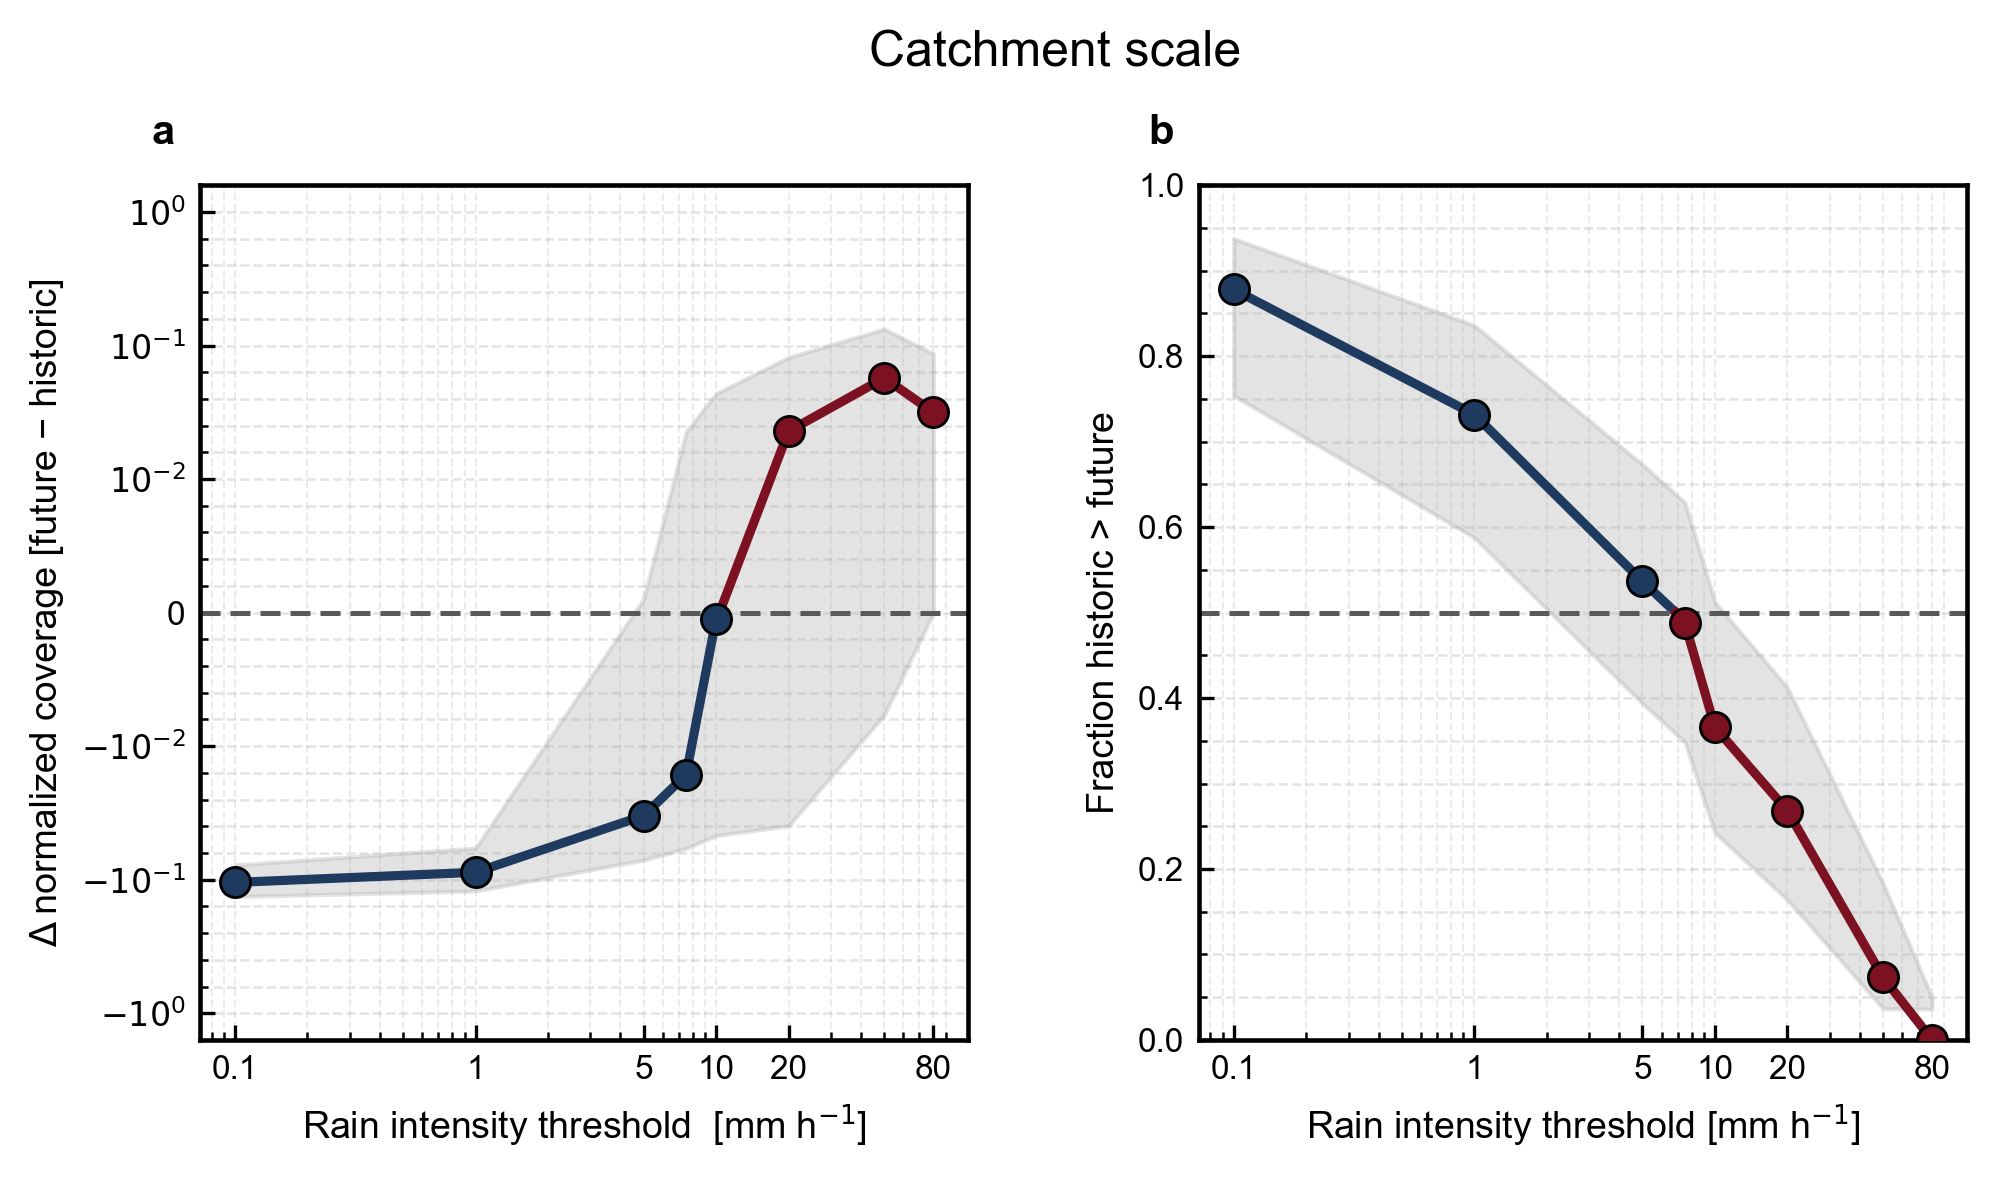

C:\Users\raznu\AppData\Local\Temp\ipykernel_38616\1704801617.py:658: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved figure to: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_3_a_b.pdf


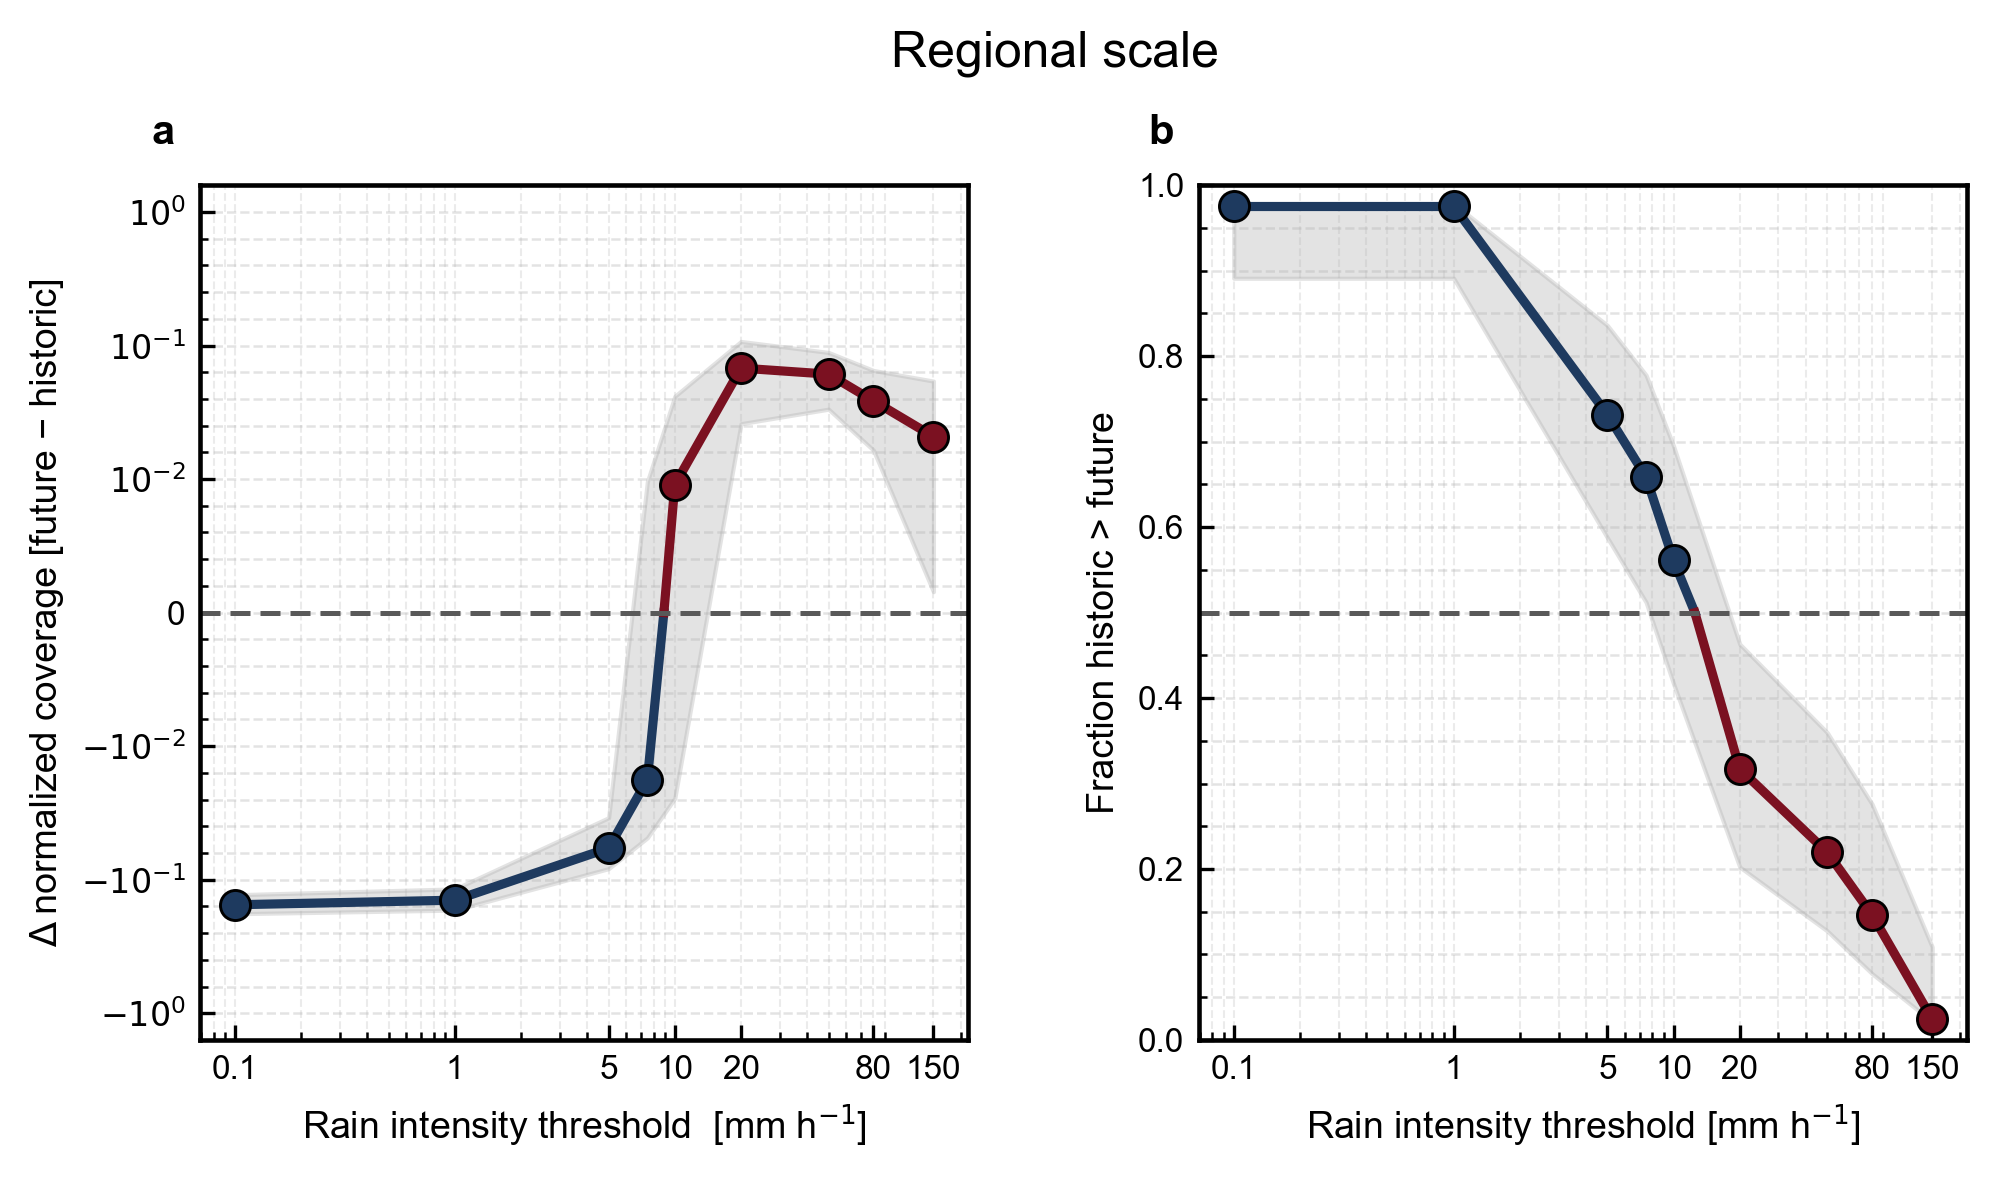

In [4]:
# ============================================
#  Rain only analysis: historical vs future
#  Basin and domain areal coverage
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from contextlib import contextmanager
from pathlib import Path
from typing import Sequence, Optional

# ---------------------------------------------------------------------
# Figure output directory (PDF)
# ---------------------------------------------------------------------

FIG_DIR = Path(
    r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
)

# ---------------------------------------------------------------------
# 1) Load both basin and domain CSV files
# ---------------------------------------------------------------------

DATASETS = {
    "Basin": r"D:\MY_CODES\UrbanRunoffModeling\04_impact_of_climate_change_and_urbanization\wrf_rainfall_analysis\basin_wet_fraction\basin_wet_fraction_events.csv",
    "Domain": r"D:\MY_CODES\UrbanRunoffModeling\04_impact_of_climate_change_and_urbanization\wrf_rainfall_analysis\domain_wet_fraction\domain_wet_fraction_events.csv",
}

# Optional per dataset thresholds to use (mm h^-1).
# None means "use all thresholds in the CSV".
THRESHOLDS_MM_HR = {
    "Basin":  [0.1, 1, 5, 7.5, 10, 20, 50, 80, 150],
    "Domain": [0.1, 1, 5, 7.5, 10, 20, 50, 80, 150],
    # "Basin": None,
}


def load_rain_summary(csv_path: str) -> pd.DataFrame:
    """
    Load a single CSV (basin or domain) and clean basic columns.

    Expected columns in the CSV:
        event_id, scenario, threshold_mm_per_hr, mean_wet_fraction

    Returns a DataFrame with columns:
        event_id (str)
        scenario (str: 'historical' or 'future')
        threshold_mm_hr (float)
        mean_wet_fraction (float, fraction 0–1)
    """
    df = pd.read_csv(csv_path)

    # Standardize threshold column name
    if "threshold_mm_hr" not in df.columns and "threshold_mm_per_hr" in df.columns:
        df = df.rename(columns={"threshold_mm_per_hr": "threshold_mm_hr"})

    expected_cols = {"event_id", "scenario", "threshold_mm_hr", "mean_wet_fraction"}
    missing = expected_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path} is missing columns: {missing}")

    # Clean types
    df["event_id"] = df["event_id"].astype(str)
    df["scenario"] = df["scenario"].astype(str)
    df["threshold_mm_hr"] = pd.to_numeric(df["threshold_mm_hr"], errors="coerce")
    df["mean_wet_fraction"] = pd.to_numeric(df["mean_wet_fraction"], errors="coerce")

    # Drop rows with invalid numeric values
    df = df.dropna(subset=["threshold_mm_hr", "mean_wet_fraction"]).reset_index(drop=True)
    return df


# ---------------------------------------------------------------------
# 2) Build paired table: historic and future side by side
# ---------------------------------------------------------------------

def build_rain_pairs(rain_df: pd.DataFrame) -> pd.DataFrame:
    """
    From long-format table (one row per event × scenario × threshold),
    build paired table with columns:
        threshold_mm_hr
        event_id
        historic_cover   (percentage)
        future_cover     (percentage)
    """
    piv = (
        rain_df
        .pivot_table(
            index=["event_id", "threshold_mm_hr"],
            columns="scenario",
            values="mean_wet_fraction",
            aggfunc="mean"
        )
        .reset_index()
    )

    # We expect columns "historical" and "future" after pivot
    for col in ("historical", "future"):
        if col not in piv.columns:
            raise ValueError(f"Scenario '{col}' missing in pivoted data")

    # Keep only rows where both scenarios are available
    piv = piv.dropna(subset=["historical", "future"]).copy()

    # Rename for clarity
    piv = piv.rename(columns={"historical": "historic_cover",
                              "future": "future_cover"})

    # If numbers are in 0–1 range, convert to percent
    max_val = float(
        np.nanmax([piv["historic_cover"].max(), piv["future_cover"].max()])
    )
    if np.isfinite(max_val) and max_val <= 1.0 + 1e-9:
        piv["historic_cover"] *= 100.0
        piv["future_cover"] *= 100.0

    return piv.sort_values(["threshold_mm_hr", "event_id"], ignore_index=True)


# ---------------------------------------------------------------------
# 3) Normalize per threshold and compute summaries
# ---------------------------------------------------------------------

def normalize_and_summarize_rain(
    pairs: pd.DataFrame,
    norm_method: str = "pooled_max_per_threshold",
    center: str = "mean",
):
    """
    Normalize historic_cover and future_cover and compute summary statistics.
    """
    if pairs.empty:
        raise ValueError("pairs is empty")

    if center not in ("mean", "median"):
        raise ValueError("center must be 'mean' or 'median'")

    data_norm = pairs.copy()
    data_norm["historic_norm"] = np.nan
    data_norm["future_norm"] = np.nan

    # Choose normalization denominator
    if norm_method == "global_hist_max":
        denom = pd.to_numeric(data_norm["historic_cover"], errors="coerce").max()
        if not np.isfinite(denom) or denom == 0:
            raise ValueError("global historic max is not finite or zero")
        data_norm["historic_norm"] = data_norm["historic_cover"] / denom
        data_norm["future_norm"] = data_norm["future_cover"] / denom

    elif norm_method == "pooled_max_per_threshold":
        # For each threshold separately, normalize by the pooled max
        for thr in np.sort(data_norm["threshold_mm_hr"].unique()):
            sel = data_norm["threshold_mm_hr"] == thr
            block = data_norm.loc[sel, ["historic_cover", "future_cover"]].to_numpy(
                dtype=float
            )
            mmax = np.nanmax(block)
            if np.isfinite(mmax) and mmax > 0:
                data_norm.loc[sel, "historic_norm"] = (
                    data_norm.loc[sel, "historic_cover"] / mmax
                )
                data_norm.loc[sel, "future_norm"] = (
                    data_norm.loc[sel, "future_cover"] / mmax
                )
    else:
        raise ValueError(
            "norm_method must be 'pooled_max_per_threshold' or 'global_hist_max'"
        )

    # Drop events that could not be normalized
    data_norm = data_norm.dropna(subset=["historic_norm", "future_norm"]).reset_index(
        drop=True
    )

    # Per threshold center (mean or median)
    agg_fun = center
    means = (
        data_norm
        .groupby("threshold_mm_hr", as_index=False)
        .agg(
            historic_center=("historic_norm", agg_fun),
            future_center=("future_norm", agg_fun),
        )
    )
    means["delta_center"] = means["future_center"] - means["historic_center"]

    # Fraction of events with historic > future
    frac_df = (
        data_norm
        .assign(historic_gt_future=lambda d: d["historic_norm"] > d["future_norm"])
        .groupby("threshold_mm_hr", as_index=False)["historic_gt_future"]
        .mean()
        .rename(columns={"historic_gt_future": "fraction_historic_gt_future"})
    )

    return data_norm, means, frac_df


# ---------------------------------------------------------------------
# 4) Helper functions for styling and transforms
# ---------------------------------------------------------------------

@contextmanager
def nature_rc():
    """
    Context manager that applies a compact 'Nature-style' rcParams block.
    """
    with plt.rc_context({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.labelsize": 9, "axes.titlesize": 10,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "axes.linewidth": 0.8,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.minor.visible": True, "ytick.minor.visible": True,
        "xtick.major.size": 3.5, "ytick.major.size": 3.5,
        "xtick.minor.size": 2.0, "ytick.minor.size": 2.0,
        "legend.frameon": False,
        "savefig.dpi": 300, "figure.dpi": 300,
    }):
        yield


def _apply_axis_nature(ax, grid_y=True, grid_x=False):
    """
    Remove top/right spines and add dashed grids (slightly denser).
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)

    if grid_y:
        ax.grid(True, axis="y", which="both",
                linestyle="--", alpha=0.35, linewidth=0.6)
    if grid_x:
        ax.grid(True, axis="x", which="both",
                linestyle="--", alpha=0.25, linewidth=0.5)


# NEW: full box around axes (requested change)
def _apply_full_axes_box(ax, lw=1.1, color="black"):
    """
    Add a full frame around the axes (all four spines).
    """
    for side in ("left", "bottom", "right", "top"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(lw)
        ax.spines[side].set_color(color)


def _adaptive_threshold_ticks(thr: Sequence[float],
                              use_log: bool,
                              max_labels: int = 6):
    """
    Choose a limited set of x ticks based on the threshold values.
    """
    x = np.asarray(thr, float)
    if x.size == 0:
        return np.array([]), []
    xs = np.log10(x) if use_log else x
    span = xs.max() - xs.min()
    if span <= 0 or max_labels < 2:
        ticks = x
    else:
        min_sep = span / (max_labels - 1) * 0.9
        chosen = [0]
        last = xs[0]
        for i in range(1, len(x) - 1):
            if xs[i] - last >= min_sep:
                chosen.append(i)
                last = xs[i]
        if chosen[-1] != len(x) - 1:
            chosen.append(len(x) - 1)
        ticks = x[np.unique(chosen)]
    labels = [f"{t:g}" for t in ticks]
    return ticks, labels


def _compute_per_event_reduce(data_norm: pd.DataFrame,
                              event_reduce: str = "mean") -> pd.DataFrame:
    """
    Reduce normalized coverage per event and threshold.
    """
    if event_reduce not in {"mean", "median"}:
        raise ValueError("event_reduce must be 'mean' or 'median'")

    agg = data_norm.groupby(["threshold_mm_hr", "event_id"], as_index=False).agg(
        historic_event=("historic_norm", event_reduce),
        future_event=("future_norm", event_reduce),
    )
    agg["delta_event"] = agg["future_event"] - agg["historic_event"]
    return agg


def _wilson_ci(p_hat: float, n: int, z: float = 1.96):
    """
    Wilson confidence interval for a binomial proportion.
    """
    if n <= 0 or not np.isfinite(p_hat):
        return np.nan, np.nan
    denom = 1 + z ** 2 / n
    center = (p_hat + z ** 2 / (2 * n)) / denom
    half = (
        z *
        np.sqrt((p_hat * (1 - p_hat) + z ** 2 / (4 * n ** 2)) / n) /
        denom
    )
    return max(0.0, center - half), min(1.0, center + half)


def _pseudo_symlog_transform(values, linthresh=1e-2):
    """
    Custom symmetric transform so that distances between:
    0, 10^-2, 10^-1, 10^0 are equal (and mirrored for negatives).

    Maps:
      0       -> 0
      ±1e-2   -> ±1
      ±1e-1   -> ±2
      ±1      -> ±3
    and interpolates smoothly between them.
    """
    v = np.asarray(values, float)
    out = np.zeros_like(v)
    s = np.sign(v)
    av = np.abs(v)

    # Region 1: |y| < linthresh -> linear: 0 .. 1
    m1 = av < linthresh
    out[m1] = s[m1] * (av[m1] / linthresh) * 1.0

    # Region 2: linthresh <= |y| < 0.1 -> log between 1 .. 2
    m2 = (av >= linthresh) & (av < 0.1)
    if np.any(m2):
        num = np.log10(av[m2]) - np.log10(linthresh)
        den = np.log10(0.1) - np.log10(linthresh)
        out[m2] = s[m2] * (1.0 + num / den * 1.0)

    # Region 3: |y| >= 0.1 -> log between 2 .. 3 (clipped up to 1)
    m3 = av >= 0.1
    if np.any(m3):
        av_clipped = np.clip(av[m3], 0.1, 1.0)
        num = np.log10(av_clipped) - np.log10(0.1)
        den = np.log10(1.0) - np.log10(0.1)
        out[m3] = s[m3] * (2.0 + num / den * 1.0)

    return out


def _plot_splitline(ax, x, y, baseline, color_pos, color_neg, **kw):
    """
    Plot a line where segments above 'baseline' use color_pos
    and segments below 'baseline' use color_neg.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    for i in range(len(x) - 1):
        x0, x1 = x[i], x[i + 1]
        y0, y1 = y[i], y[i + 1]
        if not (np.isfinite(x0) and np.isfinite(x1)
                and np.isfinite(y0) and np.isfinite(y1)):
            continue
        s0, s1 = y0 - baseline, y1 - baseline

        if s0 * s1 > 0:  # same side
            ax.plot([x0, x1], [y0, y1],
                    color=(color_pos if s0 > 0 else color_neg), **kw)
        elif s0 * s1 < 0:  # crosses baseline
            t = (baseline - y0) / (y1 - y0) if y1 != y0 else 0.5
            xc = x0 + t * (x1 - x0)
            ax.plot([x0, xc], [y0, baseline],
                    color=(color_pos if s0 > 0 else color_neg), **kw)
            ax.plot([xc, x1], [baseline, y1],
                    color=(color_pos if s1 > 0 else color_neg), **kw)
        else:  # one exactly on baseline
            ax.plot([x0, x1], [y0, y1],
                    color=(color_pos if s0 >= 0 else color_neg), **kw)


# ---------------------------------------------------------------------
# 5) Bootstrap confidence bands and neutral shading
# ---------------------------------------------------------------------

def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=0):
    """
    Simple bootstrap CI for the mean.
    """
    vals = np.asarray(values, float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        samp = rng.choice(vals, size=vals.size, replace=True)
        boots.append(np.mean(samp))

    lo = np.nanpercentile(boots, 100 * alpha / 2)
    hi = np.nanpercentile(boots, 100 * (1 - alpha / 2))
    return lo, hi


def compute_bootstrap_bands(pe_df, n_boot=2000, alpha=0.05):
    """
    Compute bootstrap confidence bands for delta_event per threshold.
    """
    rows = []
    for thr, sub in pe_df.groupby("threshold_mm_hr"):
        lo, hi = bootstrap_ci(sub["delta_event"].values,
                              n_boot=n_boot,
                              alpha=alpha)
        rows.append((thr, lo, hi))
    return pd.DataFrame(rows, columns=["threshold_mm_hr", "lo", "hi"])


def fill_band_neutral(ax, x, lo, hi, color="#B0B0B0", alpha=0.35):
    """
    Neutral CI band (no split, no baseline logic).
    Works with the custom transformed axis as well.
    """
    x = np.asarray(x, float)
    lo = np.asarray(lo, float)
    hi = np.asarray(hi, float)

    ax.fill_between(
        x,
        lo,
        hi,
        color=color,
        alpha=alpha,
        interpolate=True,
    )


# ---------------------------------------------------------------------
# 6) Final figure: delta coverage and fraction historic > future
# ---------------------------------------------------------------------

def figure_delta_and_fraction_symlog_single_color(
    data_norm: pd.DataFrame,
    means: pd.DataFrame,
    frac_df: pd.DataFrame,
    event_reduce: str = "mean",
    summary_term: str = "mean",  # kept for API compatibility
    auto_log_x: bool = True,
    band_color: str = "#B0B0B0",
    marker_edge: str = "black",
    max_xtick_labels: int = 6,
    symlog_linthresh: float = 0.01,
    symlog_base: float = 10.0,  # kept for interface
    title: Optional[str] = None,
    filename: Optional[str] = None,
    save_dir: Path = FIG_DIR,
    file_format: str = "pdf",
    show: bool = True,
):
    """
    Build the two panel figure and optionally save it as PDF.

    Parameters
    ----------
    title : str or None
        Suptitle for the figure.
    filename : str or None
        Base filename (without extension) to save as PDF.
    save_dir : Path
        Directory to save figure if filename is given.
    file_format : str
        Output format, default 'pdf'.
    show : bool
        If True, show the figure. If False, do not display it.
    """
    col_hist = "#1E3A5F"   # historic-like blue
    col_future = "#7B1121" # future-like red

    # Sort thresholds and compute summary delta per threshold
    ms = means.sort_values("threshold_mm_hr").copy()
    thr = ms["threshold_mm_hr"].astype(float).values
    ms["delta_summary"] = ms["future_center"] - ms["historic_center"]

    # Per event deltas
    pe = _compute_per_event_reduce(data_norm, event_reduce=event_reduce)

    # Bootstrap bands for delta_summary
    band = compute_bootstrap_bands(pe, n_boot=2000, alpha=0.05)
    a_df = (
        ms[["threshold_mm_hr", "delta_summary"]]
        .merge(band, on="threshold_mm_hr", how="left")
        .sort_values("threshold_mm_hr")
    )

    # Prepare data for the right panel
    n_per_thr = (
        data_norm.groupby(["threshold_mm_hr", "event_id"])
        .size()
        .reset_index()
        .groupby("threshold_mm_hr")
        .size()
        .rename("n_events")
        .reset_index()
    )

    b_df = (
        frac_df.merge(n_per_thr, on="threshold_mm_hr", how="left")
        .sort_values("threshold_mm_hr")
    )

    lohi = np.array([
        _wilson_ci(p, int(n))
        for p, n in zip(
            b_df["fraction_historic_gt_future"],
            b_df["n_events"].fillna(0),
        )
    ])
    b_df["lo"], b_df["hi"] = lohi[:, 0], lohi[:, 1]

    # Decide whether to use log x axis
    use_log = False
    if auto_log_x:
        pos = thr[thr > 0]
        use_log = len(pos) >= 2 and (pos.max() / max(pos.min(), 1e-12) >= 20)

    with nature_rc():
        fig, axs = plt.subplots(
            1, 2, figsize=(7.6, 3.7), dpi=300,
            gridspec_kw={"wspace": 0.3}
        )

        # ----------------------------------------------------------
        # (a) Left panel: Δ normalized coverage with custom Y spacing
        # ----------------------------------------------------------
        axL = axs[0]
        if use_log:
            axL.set_xscale("log")

        x = a_df["threshold_mm_hr"].to_numpy(float)
        d = a_df["delta_summary"].to_numpy(float)
        lo = a_df["lo"].to_numpy(float)
        hi = a_df["hi"].to_numpy(float)

        # Transform Y values to pseudo-symlog coordinates
        d_tr  = _pseudo_symlog_transform(d,  linthresh=symlog_linthresh)
        lo_tr = _pseudo_symlog_transform(lo, linthresh=symlog_linthresh)
        hi_tr = _pseudo_symlog_transform(hi, linthresh=symlog_linthresh)

        # Neutral CI band in transformed coordinates
        fill_band_neutral(axL, x, lo_tr, hi_tr, color=band_color, alpha=0.35)

        # Split-colored line in transformed coordinates
        _plot_splitline(axL, x, d_tr, 0.0, color_pos=col_future, color_neg=col_hist, lw=2.2)

        # Markers: future color above zero, historic color below
        pos_mask = d >= 0
        neg_mask = d < 0
        axL.scatter(
            x[pos_mask], d_tr[pos_mask], s=52,
            c=col_future,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )
        axL.scatter(
            x[neg_mask], d_tr[neg_mask], s=52,
            c=col_hist,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )

        # Horizontal zero line
        axL.axhline(0, color="0.35", lw=1.2, ls=(0, (4, 2)))
        axL.set_xlabel("Rain intensity threshold  [mm h$^{-1}$]")
        axL.set_ylabel("Δ normalized coverage [future − historic]")
        _apply_axis_nature(axL, grid_y=True, grid_x=True)
        _apply_full_axes_box(axL, lw=1.1, color="black")  # NEW

        # X ticks + force tick at threshold 10
        ticks, _ = _adaptive_threshold_ticks(thr, use_log,
                                             max_labels=max_xtick_labels)
        if np.isfinite(thr.min()) and np.isfinite(thr.max()):
            if (thr.min() <= 10.0 <= thr.max()):
                if not np.any(np.isclose(ticks, 10.0)):
                    ticks = np.sort(np.append(ticks, 10.0))
        axL.set_xticks(ticks)
        axL.set_xticklabels([f"{t:g}" for t in ticks])

        # Y limits and labels in transformed space
        axL.set_ylim(-3.2, 3.2)
        axL.set_yticks([-3, -2, -1, 0, 1, 2, 3])

        # FIX: Added minus signs to the labels corresponding to negative ticks (-3, -2, -1)
        axL.set_yticklabels(
            ["$-10^{0}$", "$-10^{-1}$", "$-10^{-2}$", "0",
             "$10^{-2}$", "$10^{-1}$", "$10^{0}$"]
        )

        axL.annotate("a", xy=(0, 1), xycoords="axes fraction",
                     xytext=(-6, 8), textcoords="offset points",
                     ha="right", va="bottom", fontweight="bold")

        # ----------------------------------------------------------
        # (b) Right panel: fraction historic > future
        # ----------------------------------------------------------
        axR = axs[1]
        if use_log:
            axR.set_xscale("log")

        x2 = b_df["threshold_mm_hr"].to_numpy(float)
        y = b_df["fraction_historic_gt_future"].to_numpy(float)
        lo2 = b_df["lo"].to_numpy(float)
        hi2 = b_df["hi"].to_numpy(float)
        base = 0.5  # equal probability

        # Neutral CI band on [0,1]
        fill_band_neutral(axR, x2, lo2, hi2, color=band_color, alpha=0.35)

        # Split-colored line around 0.5
        _plot_splitline(axR, x2, y, base, color_pos=col_hist, color_neg=col_future, lw=2.2)

        # Markers
        pos2 = y >= base
        neg2 = y < base
        axR.scatter(
            x2[pos2], y[pos2], s=52,
            c=col_hist,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )
        axR.scatter(
            x2[neg2], y[neg2], s=52,
            c=col_future,
            edgecolors=marker_edge, linewidths=0.7, zorder=3
        )

        axR.axhline(base, color="0.35", lw=1.2, ls=(0, (4, 2)))
        axR.set_ylim(0, 1)
        axR.set_xlabel("Rain intensity threshold [mm h$^{-1}$]")
        axR.set_ylabel("Fraction historic > future")
        _apply_axis_nature(axR, grid_y=True, grid_x=True)
        _apply_full_axes_box(axR, lw=1.1, color="black")  # NEW

        ticks2, _ = _adaptive_threshold_ticks(thr, use_log,
                                              max_labels=max_xtick_labels)
        if np.isfinite(thr.min()) and np.isfinite(thr.max()):
            if (thr.min() <= 10.0 <= thr.max()):
                if not np.any(np.isclose(ticks2, 10.0)):
                    ticks2 = np.sort(np.append(ticks2, 10.0))
        axR.set_xticks(ticks2)
        axR.set_xticklabels([f"{t:g}" for t in ticks2])

        axR.annotate("b", xy=(0, 1), xycoords="axes fraction",
                     xytext=(-6, 8), textcoords="offset points",
                     ha="right", va="bottom", fontweight="bold")

        # Figure title
        if title is not None:
            fig.suptitle(title, y=1.02)

        plt.tight_layout()

        # Save as PDF if requested
        if filename is not None:
            save_dir.mkdir(parents=True, exist_ok=True)
            out_path = save_dir / f"{filename}.{file_format}"
            fig.savefig(out_path, bbox_inches="tight")
            print(f"Saved figure to: {out_path}")

        if show:
            plt.show()
        else:
            plt.close(fig)

        return fig, axs


# ---------------------------------------------------------------------
# 7) Run the full pipeline for both Basin and Domain
# ---------------------------------------------------------------------

if __name__ == "__main__":

    for label, csv_path in DATASETS.items():
        rain_summary_df = load_rain_summary(csv_path)

        # Optional threshold filtering per dataset
        thr_list = THRESHOLDS_MM_HR.get(label)
        if thr_list is not None:
            thr_arr = np.asarray(thr_list, float)
            rain_summary_df = rain_summary_df[
                rain_summary_df["threshold_mm_hr"].isin(thr_arr)
            ].copy()

        if rain_summary_df.empty:
            raise ValueError(f"No data left after threshold filtering for {label}")

        rain_pairs = build_rain_pairs(rain_summary_df)

        data_norm, means, frac_df = normalize_and_summarize_rain(
            rain_pairs,
            norm_method="pooled_max_per_threshold",
            center="mean",
        )

        # Title and filename per scale
        if label == "Basin":
            title = "Catchment scale"
            filename = "Fig_3_c_d"
        elif label == "Domain":
            title = "Regional scale"
            filename = "Fig_3_a_b"
        else:
            title = f"{label} rain areal coverage"
            filename = f"Fig_3_{label.lower()}"

        figure_delta_and_fraction_symlog_single_color(
            data_norm,
            means,
            frac_df,
            event_reduce="mean",
            summary_term="mean",
            title=title,
            filename=filename,
            save_dir=FIG_DIR,
            file_format="pdf",
            show=True,
        )
